### Nhập dữ liệu

In [606]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import lognorm
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import kurtosis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Tổng quan bộ dữ liệu

In [607]:
# 🔹 Đọc dữ liệu
df = pd.read_csv('hotel_bookings.csv')
print(df.shape)
print(df.info())

# 🔹 Xem 5 dòng đầu tiên
df.head(5)

(119390, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  mea

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02/07/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02/07/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03/07/2015


#### Thuộc tính số (Numerical Attributes)

- is_canceled: Cho biết phòng được đặt có bị hủy không (1 = Hủy, 0 = Không hủy).
- lead_time: Số ngày giữa thời điểm đặt phòng và ngày đến.
- arrival_date_year: Năm của ngày đến.
- arrival_date_week_number: Tuần trong năm của ngày đến.
- arrival_date_day_of_month: Ngày trong tháng của ngày đến.
- stays_in_weekend_nights: Số đêm cuối tuần (Thứ Bảy, Chủ Nhật) khách ở hoặc đặt.
- stays_in_week_nights: Số đêm trong tuần (Thứ Hai–Thứ Sáu) khách ở hoặc đặt.
- adults: Số lượng người lớn trong đặt phòng.
- children: Số lượng trẻ em trong đặt phòng.
- babies: Số lượng trẻ sơ sinh trong đặt phòng.
- previous_cancellations: Số lần đặt phòng trước đó bị hủy của khách.
- previous_bookings_not_canceled: Số lần đặt phòng trước đó không bị hủy.
- booking_changes: Số lần thay đổi trong đặt phòng.
- days_in_waiting_list: Số ngày đặt phòng nằm trong danh sách chờ.
- adr: Giá trung bình mỗi đêm (Average Daily Rate).
- required_car_parking_spaces: Số chỗ đậu xe yêu cầu.
- total_of_special_requests: Tổng số yêu cầu đặc biệt từ khách.

#### Thuộc tính phân loại (Categorical Attributes)

- hotel: Loại khách sạn (ví dụ: City Hotel, Resort Hotel).
- arrival_date_month: Tháng của ngày đến.
- meal: Loại gói ăn được đặt.
- country: Quốc gia xuất xứ của khách.
- market_segment: Phân khúc thị trường (ví dụ: Online TA, Groups).
- distribution_channel: Kênh đặt phòng (ví dụ: Direct, Corporate).
- is_repeated_guest: Khách đã từng ở khách sạn trước đây (1 = Có, 0 = Không).
- reserved_room_type: Loại phòng được đặt.
- assigned_room_type: Loại phòng được sắp xếp.
- deposit_type: Loại đặt cọc (ví dụ: No Deposit, Refundable).
- customer_type: Loại khách hàng (ví dụ: Transient, Group).
- reservation_status: Trạng thái hiện tại của đặt phòng (Canceled, No-Show, Checked-Out).
- reservation_status_date: Ngày cập nhật trạng thái gần nhất.

#### Thuộc tính bổ sung (Additional Attributes)

- agent: ID của đại lý du lịch.
- company: ID công ty thực hiện đặt phòng.


##### Các cột 'is_repeated_guest' và 'is_canceled' nên có kiểu dữ liệu boolean. Tuy nhiên, kết quả ở ô trên cho thấy chúng đang có kiểu dữ liệu integer. Vì vậy, cần chuyển kiểu dữ liệu của chúng sang bool.

In [608]:
df[['is_repeated_guest','is_canceled']] = df[['is_repeated_guest','is_canceled']].astype(bool)
print(df['is_repeated_guest'].dtype)

bool


### Kiểu tra bất thường trong bộ dữ liệu


#### Kiểm tra missing value :

In [609]:
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

 **Thấy được**
Các cột có missing values:
`country`: 488 missing values
`agent`: 16340 missing values
`company`: 112593 missing values

#### Kiểm tra trùng lặp : 

In [610]:
# Tìm các hàng trùng lặp
duplicated_rows = df[df.duplicated()]

print(f"Tổng số hàng trùng lặp: {len(duplicated_rows)}")
print("\nSố lượng giá trị không null theo từng cột:")
print(duplicated_rows.count())

Tổng số hàng trùng lặp: 31994

Số lượng giá trị không null theo từng cột:
hotel                             31994
is_canceled                       31994
lead_time                         31994
arrival_date_year                 31994
arrival_date_month                31994
arrival_date_week_number          31994
arrival_date_day_of_month         31994
stays_in_weekend_nights           31994
stays_in_week_nights              31994
adults                            31994
children                          31994
babies                            31994
meal                              31994
country                           31958
market_segment                    31994
distribution_channel              31994
is_repeated_guest                 31994
previous_cancellations            31994
previous_bookings_not_canceled    31994
reserved_room_type                31994
assigned_room_type                31994
booking_changes                   31994
deposit_type                      31994
agent 

#### Kiểm tra outlier

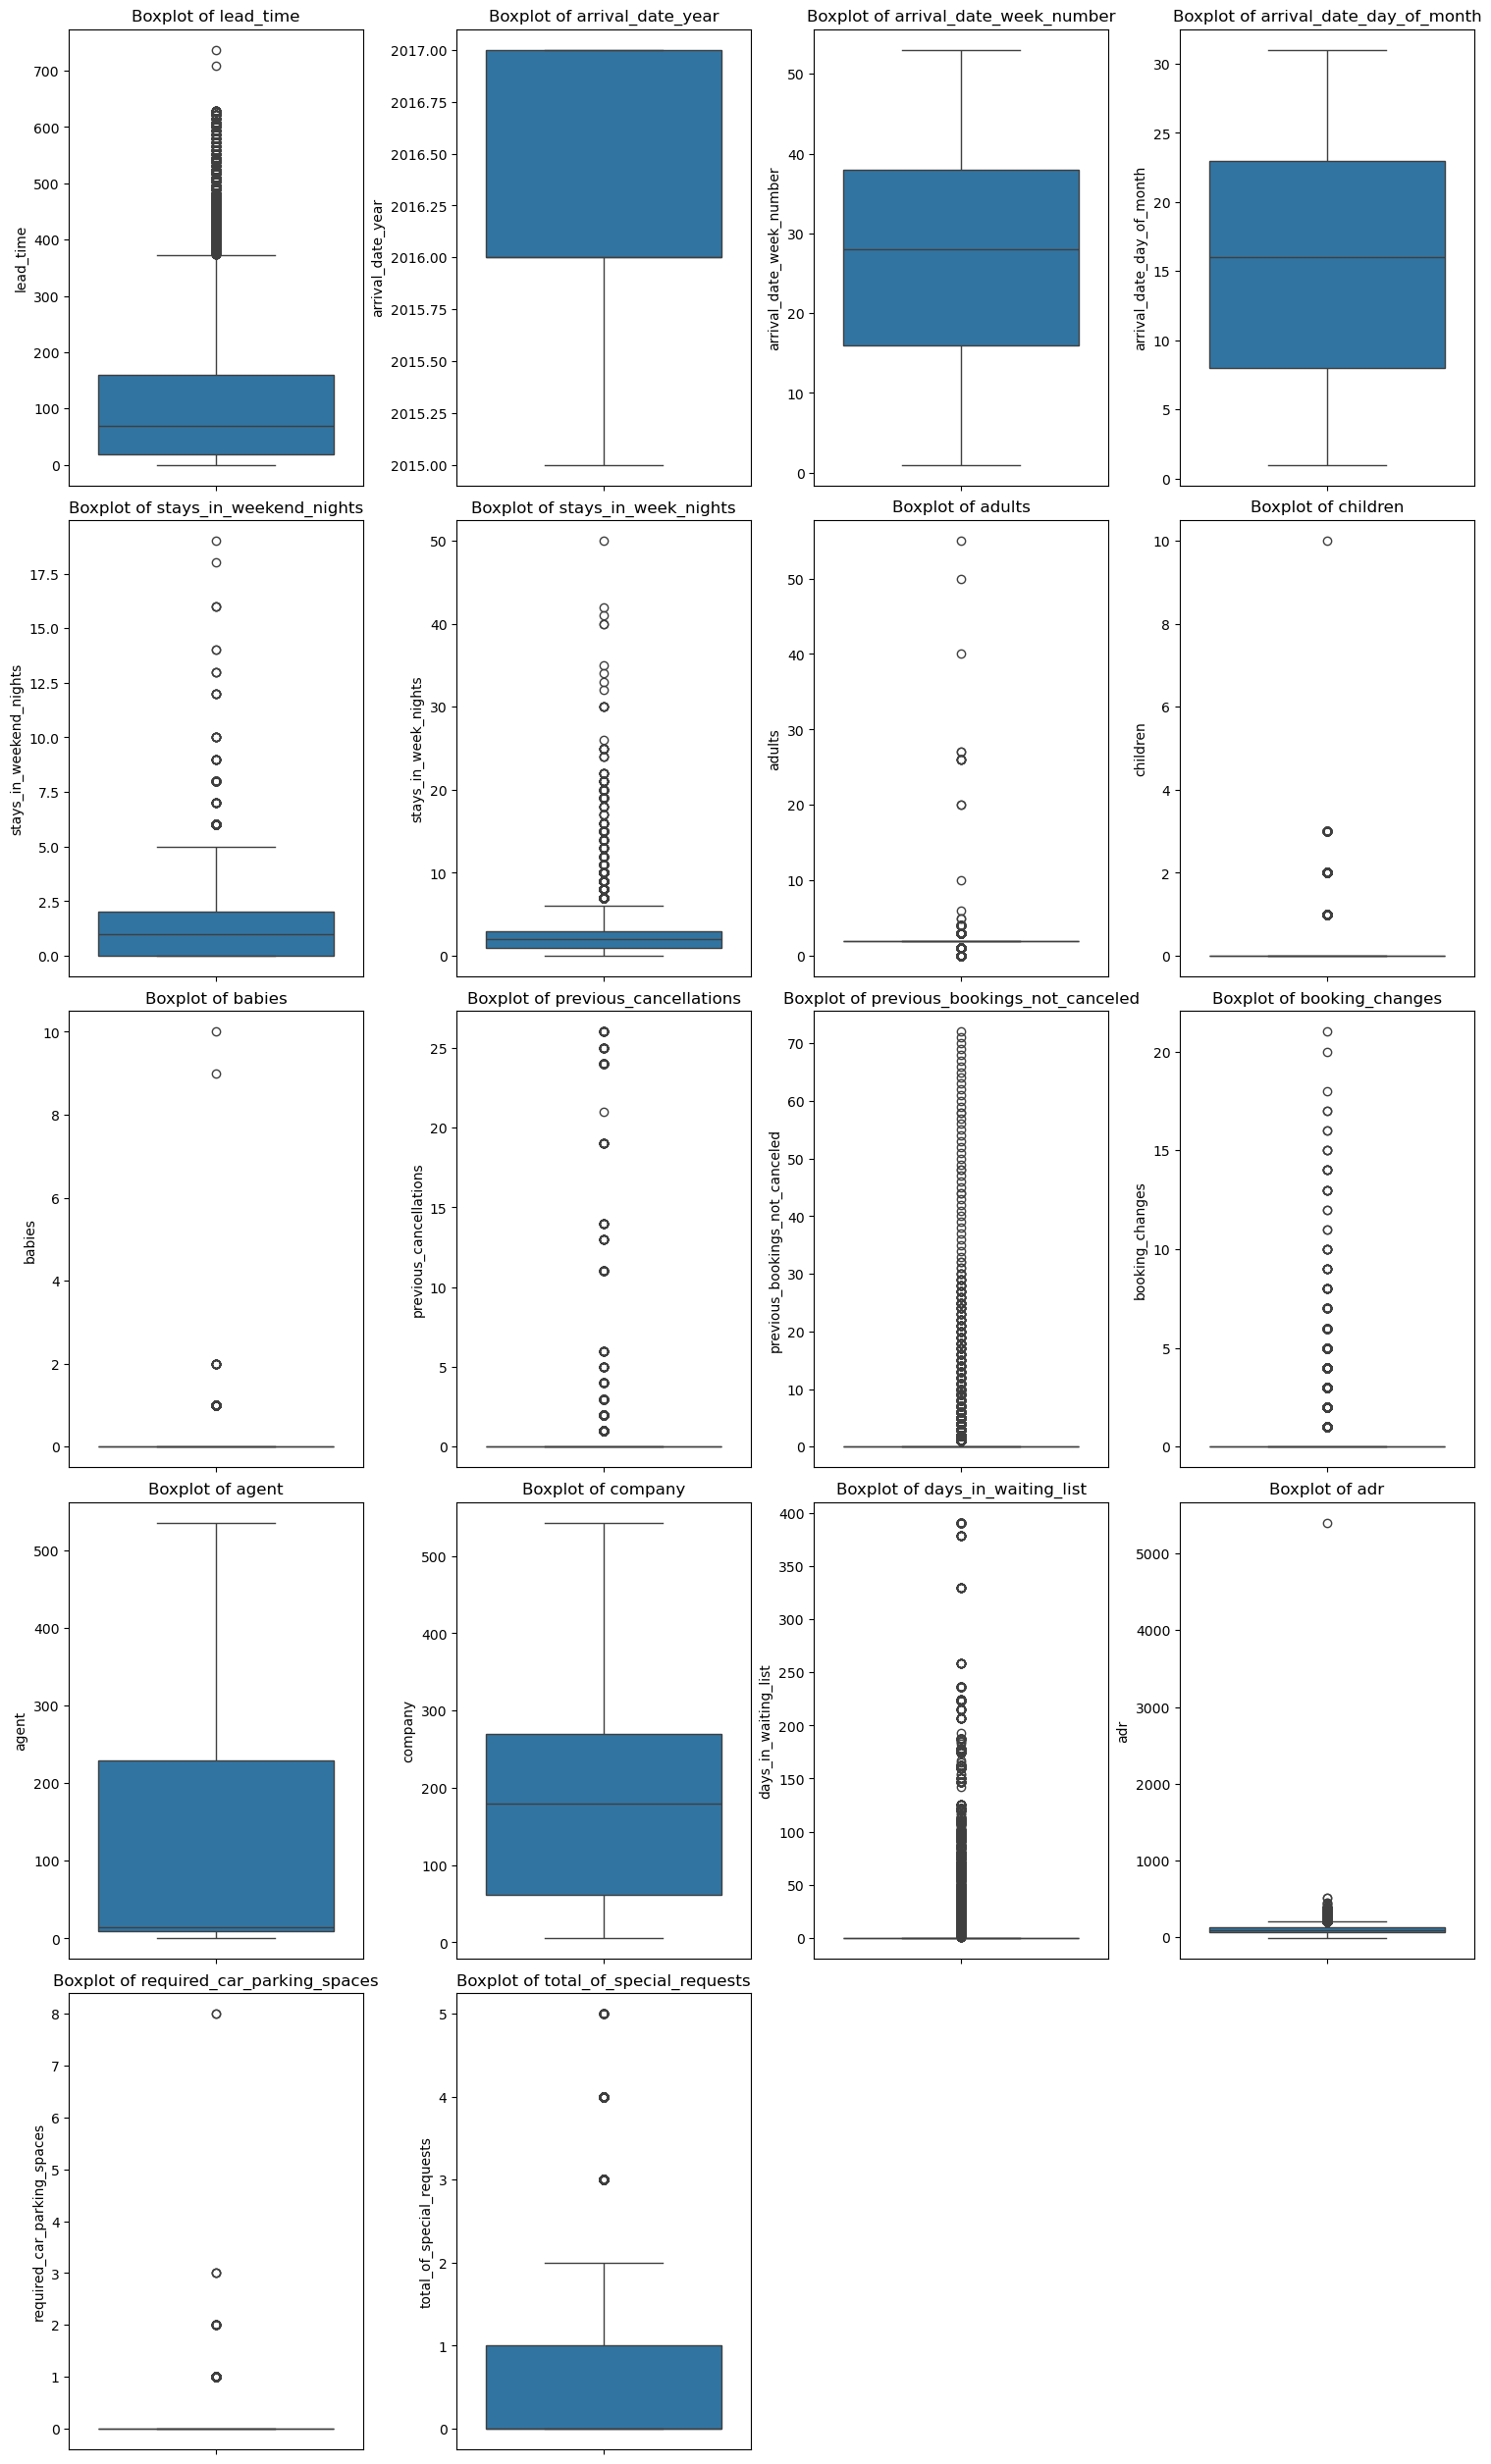

In [611]:
numeric_cols = df.select_dtypes(include=['number']).columns

# Define rows and columns based on the number of numeric columns
num_plots = len(numeric_cols)
columns = 4
rows = math.ceil(num_plots / columns)  # Calculate the number of rows needed

# Create subplots grid
fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows), constrained_layout=True)

# Flatten axes array for easy indexing
axes = axes.flatten()

# Plot each numeric column
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel("")  # Remove x-label for better spacing

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Delete extra axes

# Show the plots
plt.show()

### Phân tích đơn biến (Univariate analysis): 


##### Thống kê tóm tắt các cột có định dạng giá trị là số


In [612]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
print(df[numeric_columns].describe())

           lead_time  arrival_date_year  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights         adults       children  \
count  119390.000000      119390.000000             119390.000000              119390.000000            119390.000000         119390.000000  119390.000000  119386.000000   
mean      104.011416        2016.156554                 27.165173                  15.798241                 0.927599              2.500302       1.856403       0.103890   
std       106.863097           0.707476                 13.605138                   8.780829                 0.998613              1.908286       0.579261       0.398561   
min         0.000000        2015.000000                  1.000000                   1.000000                 0.000000              0.000000       0.000000       0.000000   
25%        18.000000        2016.000000                 16.000000                   8.000000                 0.000000              1.00

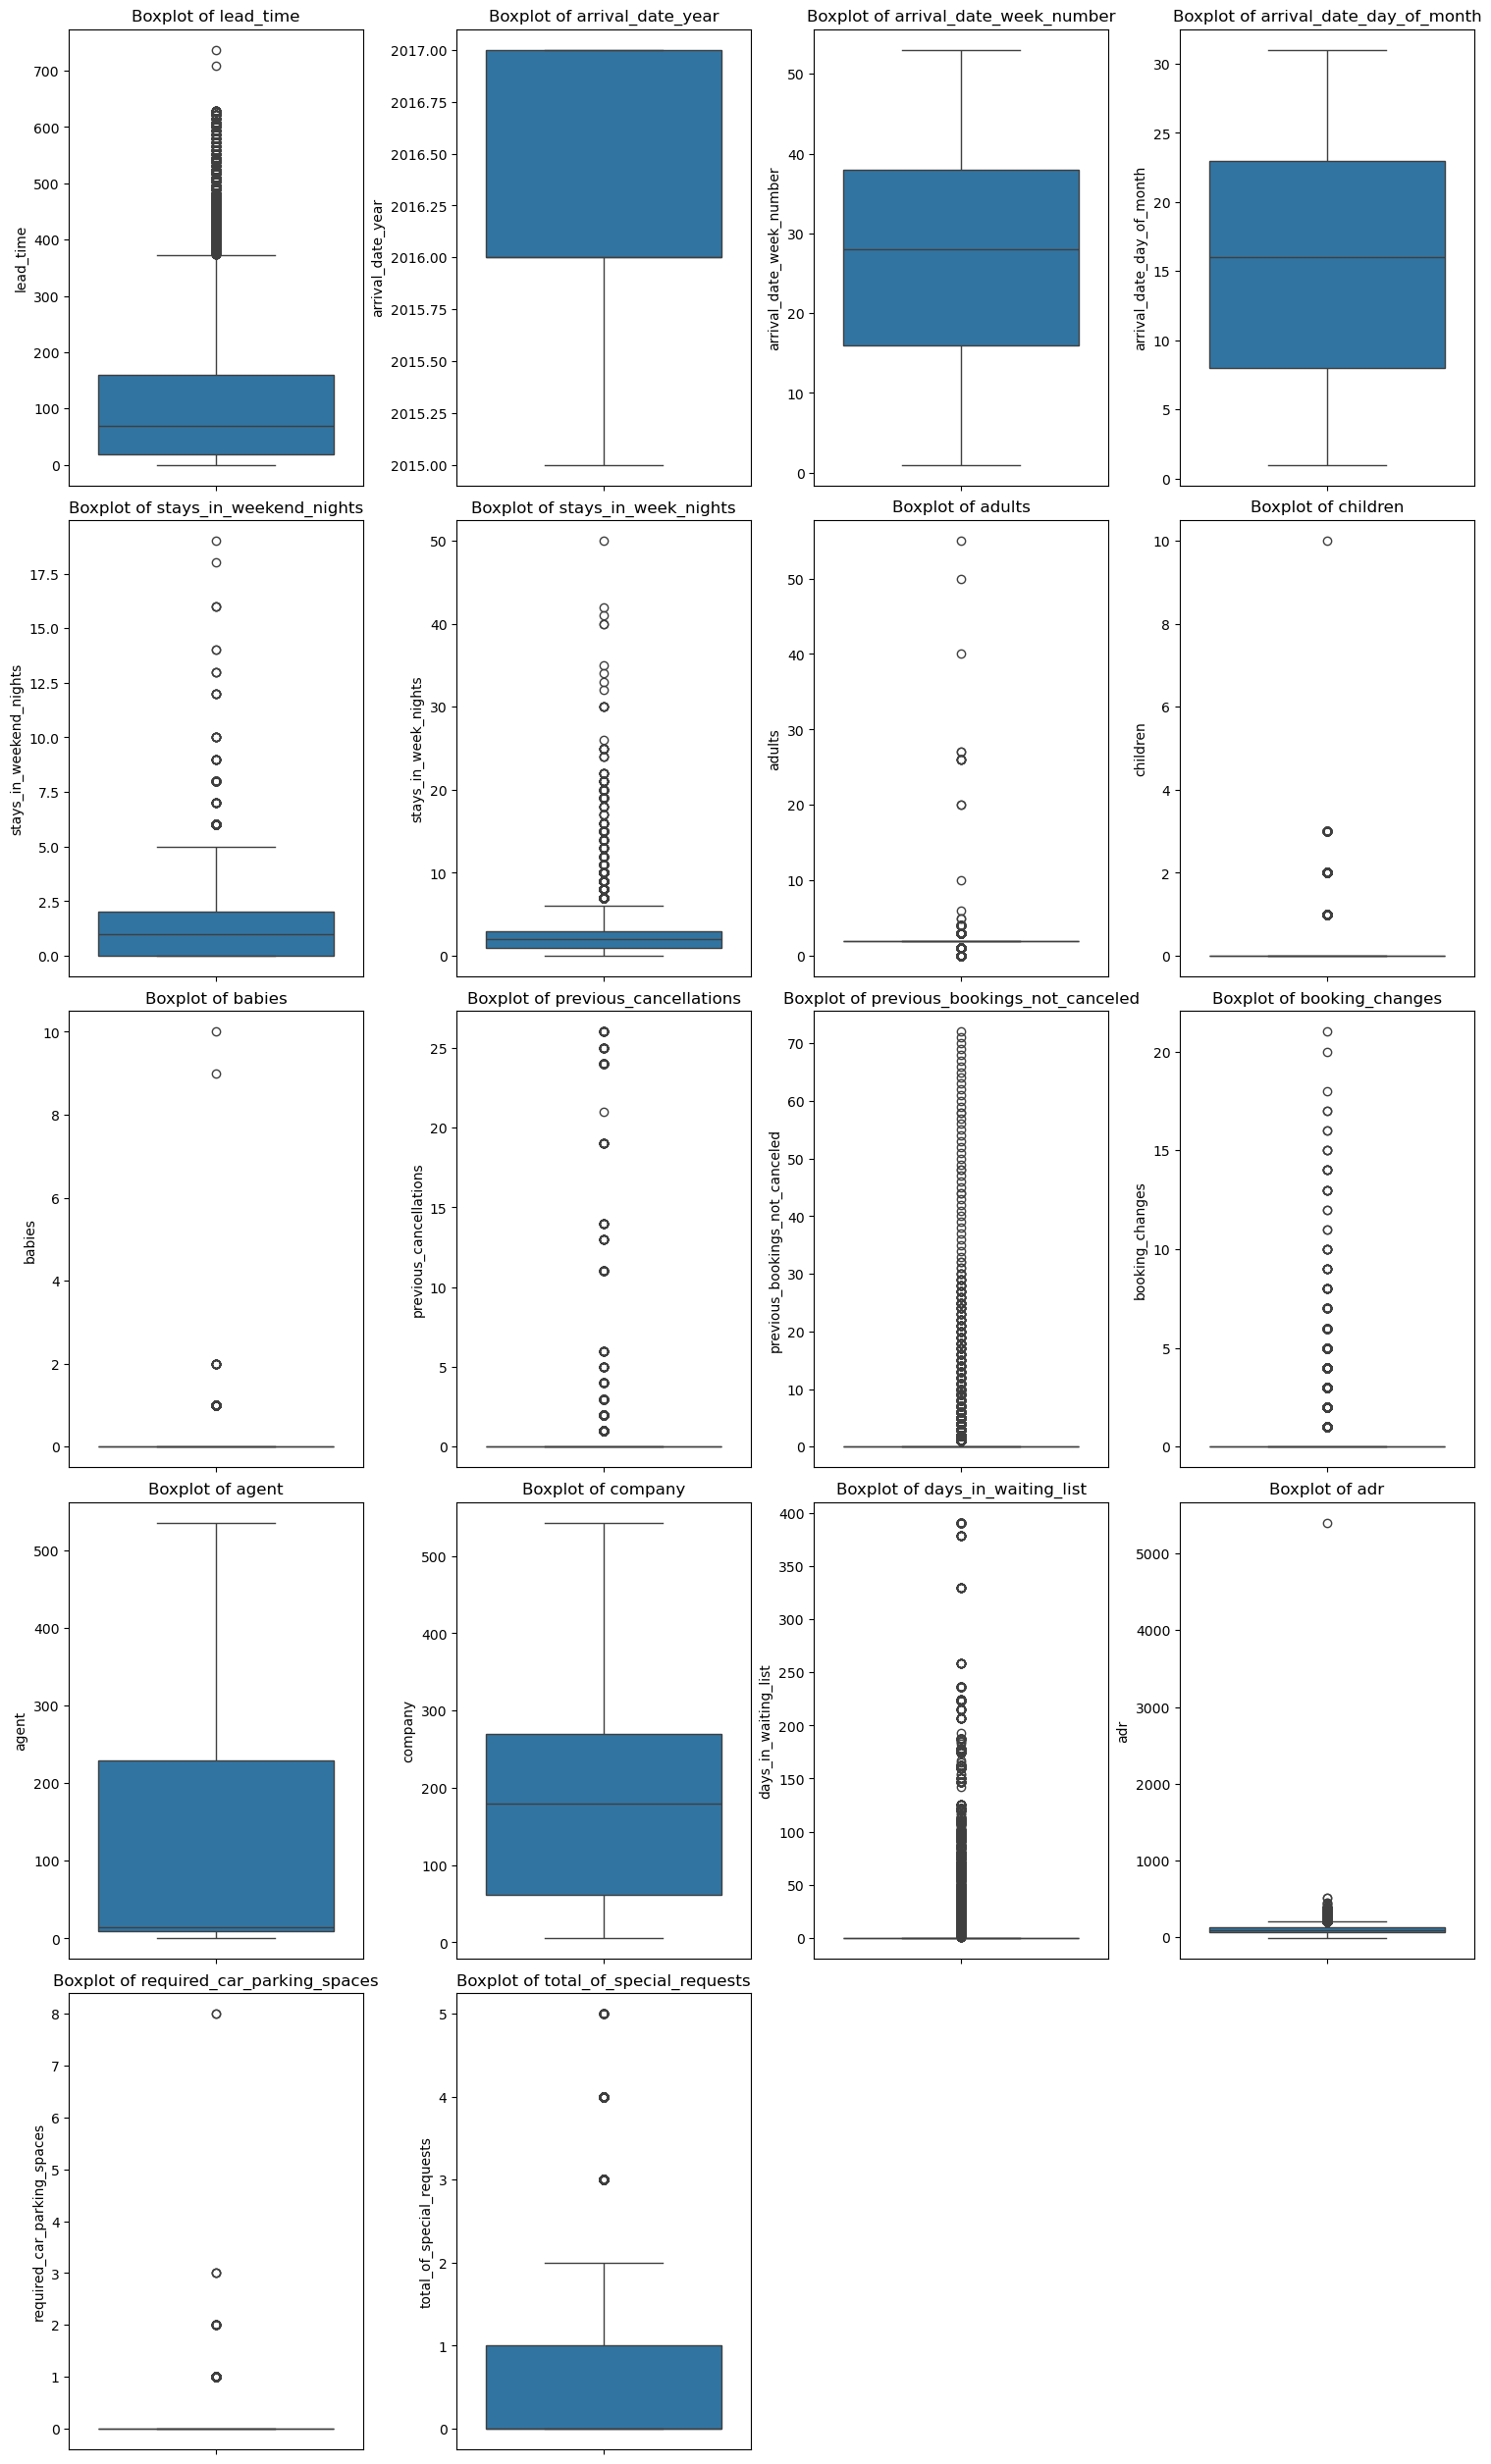

In [613]:
numeric_cols = df.select_dtypes(include=['number']).columns

# Define rows and columns based on the number of numeric columns
num_plots = len(numeric_cols)
columns = 4
rows = math.ceil(num_plots / columns)  # Calculate the number of rows needed

# Create subplots grid
fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows), constrained_layout=True)

# Flatten axes array for easy indexing
axes = axes.flatten()

# Plot each numeric column
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel("")  # Remove x-label for better spacing

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Delete extra axes

# Show the plots
plt.show()

#### Xử lí Oulier

##### Kết quả phân tích đơn biến (Univariate Analysis)

Các phát hiện chính như sau:

- Phân bố của biến hủy đặt phòng (cancellation) theo giá trị True/False: Thống kê cho thấy tỉ lệ khách hủy so với không hủy. Giúp hiểu được biến mục tiêu (target variable) có cân bằng hay lệch về một phía.

- Biến mục tiêu “lead time” bị lệch phải mạnh (positively skewed): Giá trị của “lead time” (số giờ trước khi khách đến thực tế) phần lớn là nhỏ, nhưng có một số giá trị lớn kéo dài về bên phải. Điều này làm trung bình bị kéo lên, không phản ánh đúng “giá trị điển hình”.

- Đường phân bố của lead time có hình Platykurtic (đỉnh thấp, rộng và đuôi ngắn, mỏng). Điều này có nghĩa là dữ liệu phân tán rộng, ít tập trung quanh trung bình, các giá trị cực đoan (outliers) ít hơn so với phân bố chuẩn.

- Dữ liệu Lead Time theo giờ gần giống phân bố log-normal hơn là phân bố chuẩn. Điều này phù hợp với dữ liệu thời gian, vốn không thể âm và thường có một số giá trị rất lớn (long tail).

##### Thống kê tóm tắt các cột có định dạng giá trị là số


In [614]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
print(df[numeric_columns].describe())

           lead_time  arrival_date_year  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights         adults       children  \
count  119390.000000      119390.000000             119390.000000              119390.000000            119390.000000         119390.000000  119390.000000  119386.000000   
mean      104.011416        2016.156554                 27.165173                  15.798241                 0.927599              2.500302       1.856403       0.103890   
std       106.863097           0.707476                 13.605138                   8.780829                 0.998613              1.908286       0.579261       0.398561   
min         0.000000        2015.000000                  1.000000                   1.000000                 0.000000              0.000000       0.000000       0.000000   
25%        18.000000        2016.000000                 16.000000                   8.000000                 0.000000              1.00

##### **Xu hướng trung tâm**  :  
 

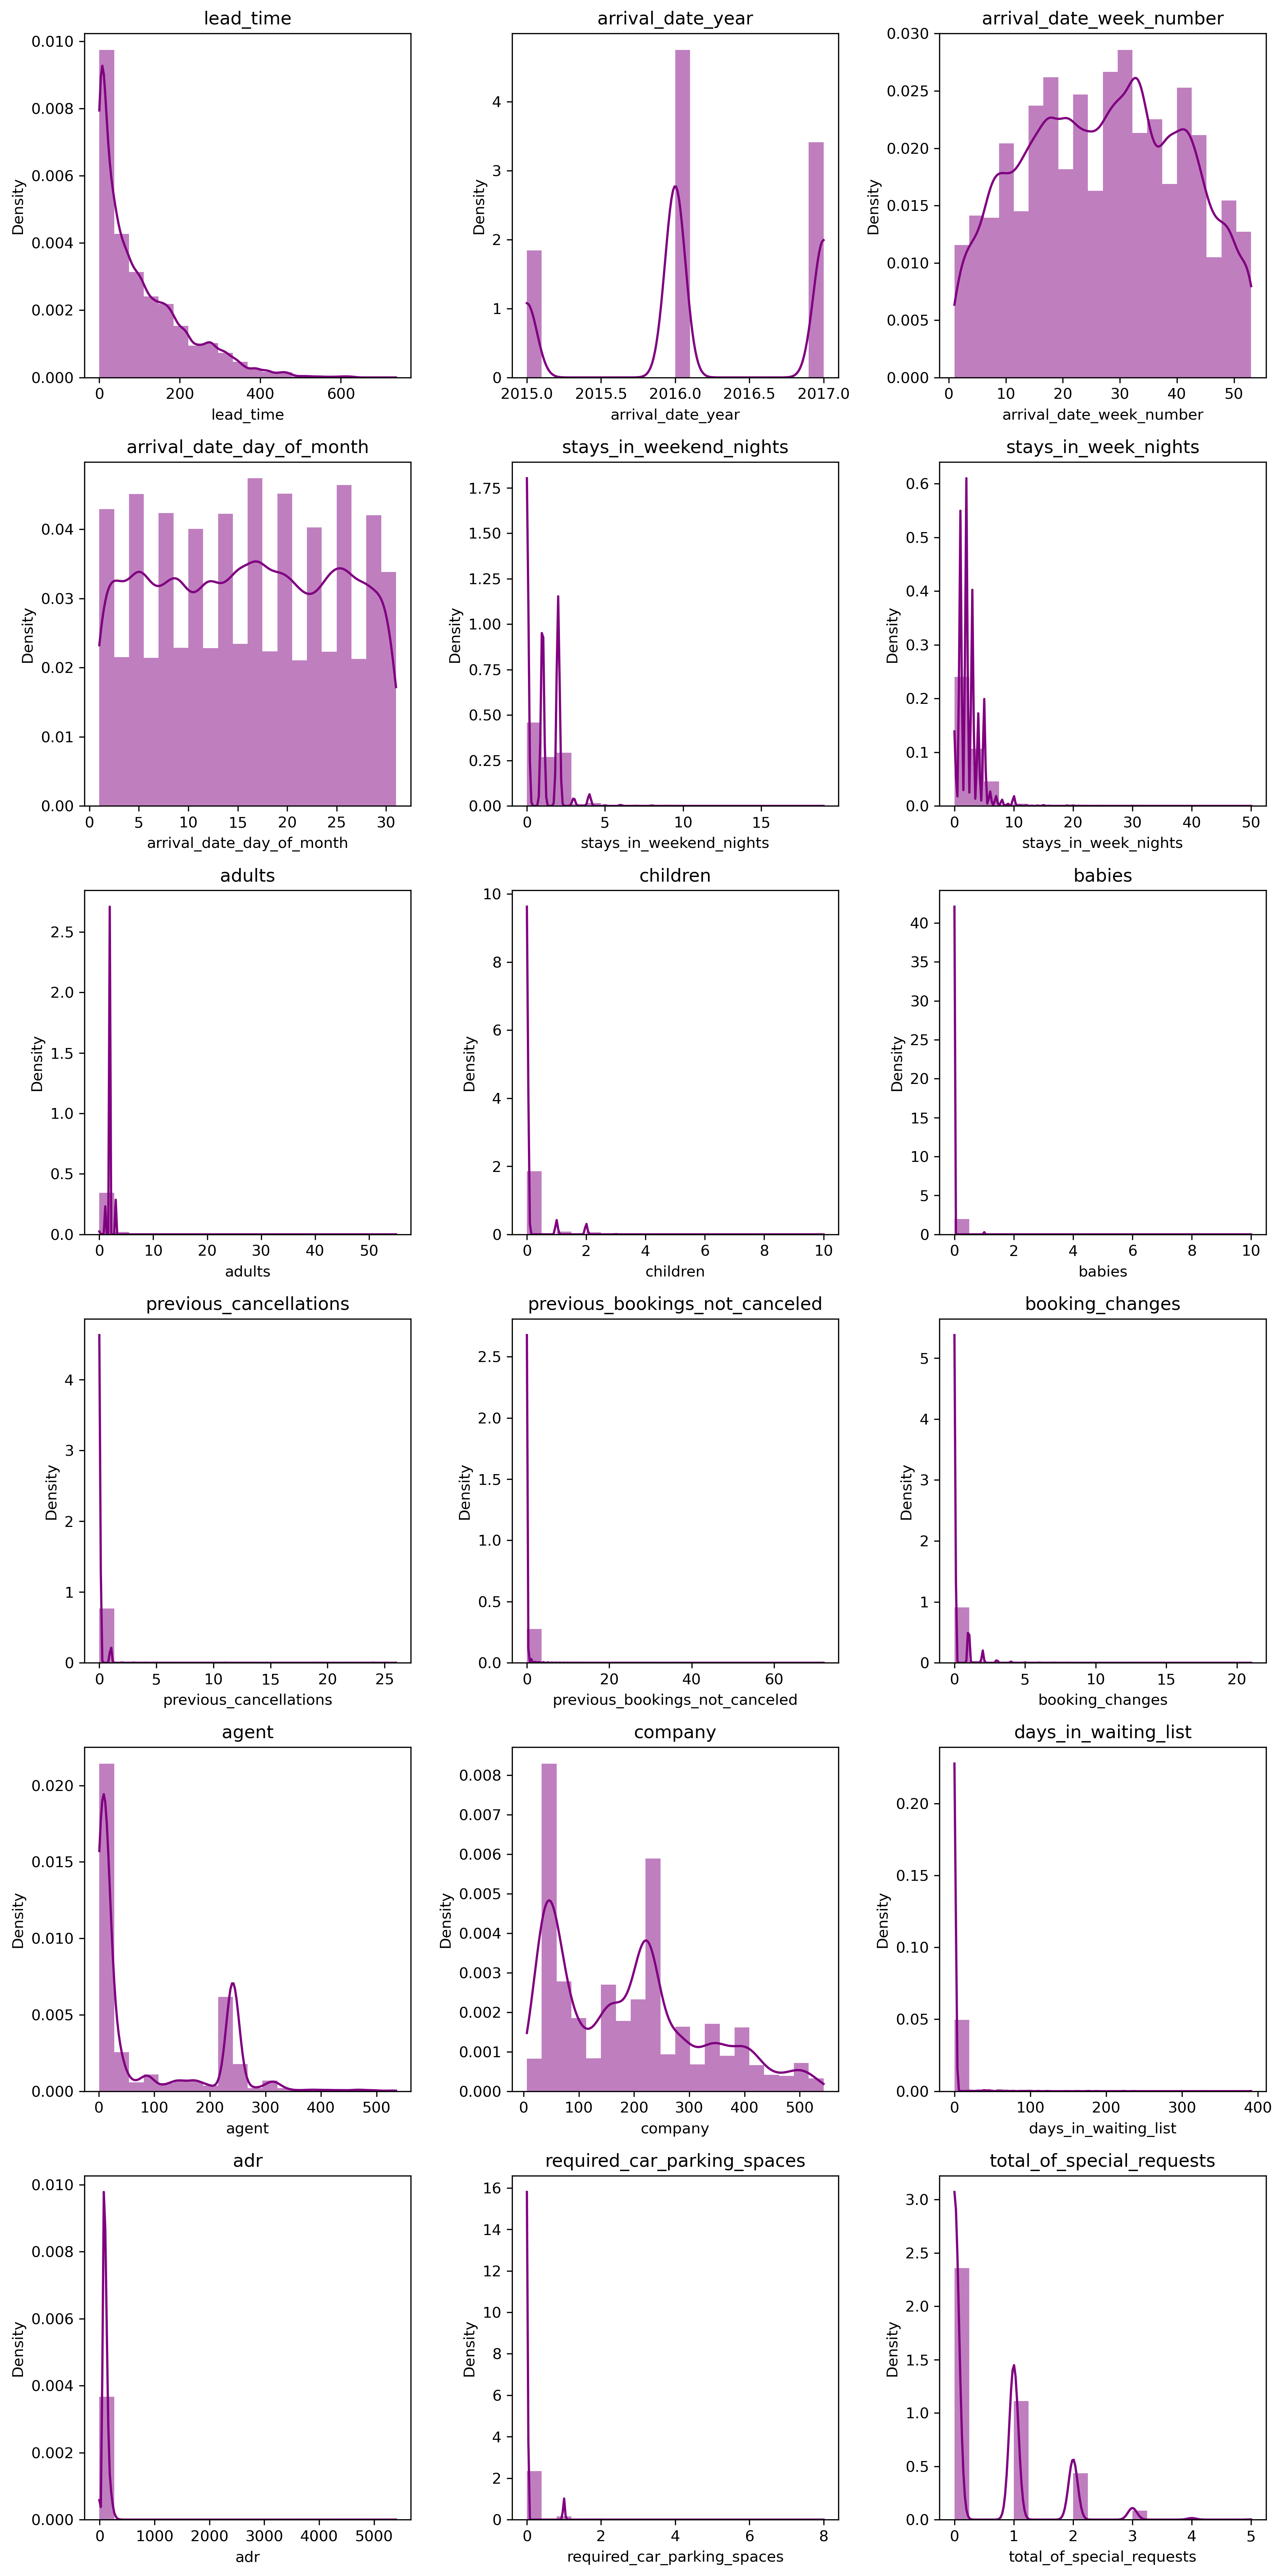

In [615]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the number of rows and columns needed
num_plots = len(numeric_columns)
cols = 3  # Fixed number of columns
rows = int(np.ceil(num_plots / cols))  # Dynamically calculate the number of rows

plt.figure(figsize=(12, rows * 4), dpi=300)

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(rows, cols, i)
    try:
        sns.histplot(df[col].dropna(), kde=True, bins=20, color='Purple', stat='density', linewidth=0)
        plt.title(col)
    except Exception as e:
        plt.text(0.5, 0.5, f"Lỗi: {e}", ha='center', va='center')
    plt.tight_layout()

plt.show()

**Lead Time (Thời gian đặt trước)**
- Phân bố của lead time lệch phải, cho thấy hầu hết các đặt phòng được thực hiện gần ngày đến, trong khi một số ít được đặt trước rất lâu. Điều này gợi ý rằng phần lớn khách lập kế hoạch ở phút chót, nhưng vẫn có một số khách lên kế hoạch từ trước.

**Arrival Date Year (Năm đến)**
- Phân bố năm đến tập trung vào một số năm cụ thể, với xu hướng tăng nhẹ theo thời gian. Điều này có thể phản ánh sự gia tăng tổng thể trong số lượng đặt phòng hoặc các biến động theo mùa trong hành vi du lịch.

**Stays in Weekend Nights (Số đêm cuối tuần)**
- Phân bố lệch phải, với hầu hết khách chỉ lưu trú ngắn trong cuối tuần. Một số ít khách kéo dài kỳ nghỉ cuối tuần, có thể do dịp đặc biệt hoặc kỳ nghỉ dài hơn.

**Stays in Week Nights (Số đêm trong tuần)**
- Tương tự như cuối tuần, phân bố cũng lệch phải. Hầu hết khách lưu trú ngắn trong tuần, một số ít chọn ở lâu hơn, có thể vì công việc hoặc nghỉ dưỡng.

**Adults, Children, and Babies (Người lớn, trẻ em, và em bé)**
- Hầu hết đặt phòng chỉ có người lớn, ít đặt có trẻ em hoặc em bé. Điều này cho thấy đa số khách là cặp đôi hoặc đi một mình.

**Previous Cancellations and Bookings Not Canceled (Hủy trước và đặt trước chưa hủy)**
- Phân bố lệch phải, cho thấy hầu hết khách có lịch sử đặt phòng “sạch” với ít hủy. Một số ít khách có tỷ lệ hủy cao, có thể là vấn đề cần lưu ý trong quản lý doanh thu.

**Booking Changes (Thay đổi đặt phòng)**
- Phân bố lệch phải, hầu hết khách ít hoặc không thay đổi đặt phòng. Một số ít khách thay đổi nhiều lần, thể hiện sự không chắc chắn hoặc linh hoạt trong kế hoạch du lịch.

**Kết luận**
- Lệch phải của lead time và số đêm lưu trú cho thấy hầu hết khách thích các chuyến đi ngắn và linh hoạt.
- Sự xuất hiện của outliers trong số đêm lưu trú và thay đổi đặt phòng gợi ý cần marketing nhắm mục tiêu hoặc chính sách đặt phòng linh hoạt.
- Phân bố người lớn, trẻ em, em bé nhấn mạnh tầm quan trọng của việc phục vụ khách trưởng thành, đồng thời cân nhắc các lựa chọn thân thiện với gia đình.




In [616]:
df['arrival_date_month'].value_counts()

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

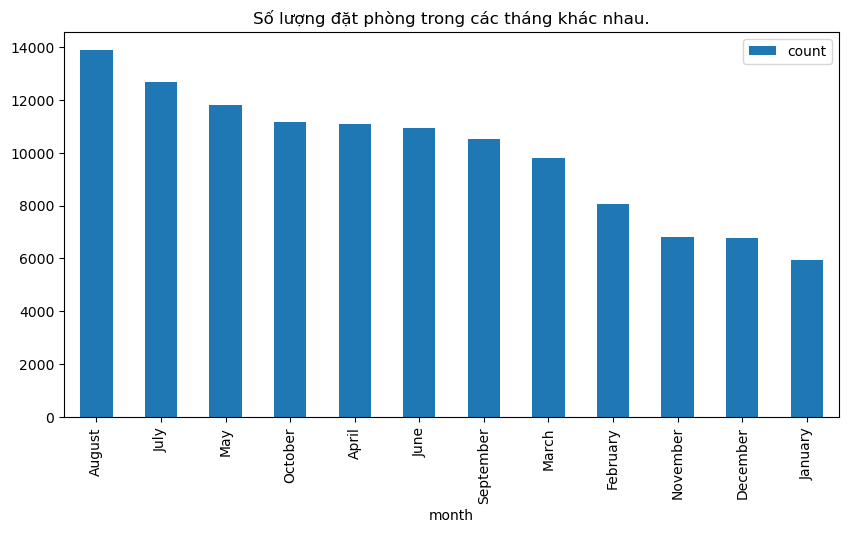

In [617]:
df['arrival_date_month'].value_counts().plot(kind = 'bar', figsize=(10,5))
plt.title('Số lượng đặt phòng trong các tháng khác nhau.')
plt.xlabel('month')
plt.legend()
plt.show()

#### Nhận xét
- Giai đoạn đặt phòng cao điểm: Tháng 8 có số lượng đặt phòng cao nhất, theo sau là tháng 7 và tháng 5. Những tháng này có thể là mùa cao điểm, có khả năng do kỳ nghỉ hè hoặc các sự kiện đặc biệt làm nhu cầu tăng mạnh.

- Các tháng như tháng 10, tháng 4 và tháng 6 có lượng đặt phòng ổn định và ở mức trung bình. Điều này cho thấy nhu cầu tương đối đều nhưng không đạt mức cao điểm.

- Giai đoạn đặt phòng thấp: Tháng 1 có số lượng đặt phòng thấp nhất, theo sau là tháng 12 và tháng 11. Đây có thể là mùa thấp điểm, có thể do thời tiết lạnh, kỳ nghỉ lễ hoặc các yếu tố khác làm giảm hoạt động đặt phòng.

### Khoảng giá trị độ lệch (Skewness)

In [618]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns 
df[numeric_columns].skew()

lead_time                          1.346550
arrival_date_year                 -0.232583
arrival_date_week_number          -0.010014
arrival_date_day_of_month         -0.002000
stays_in_weekend_nights            1.380046
stays_in_week_nights               2.862249
adults                            18.317805
children                           4.112590
babies                            24.646545
previous_cancellations            24.458049
previous_bookings_not_canceled    23.539800
booking_changes                    6.000270
agent                              1.089386
company                            0.601600
days_in_waiting_list              11.944353
adr                               10.530214
required_car_parking_spaces        4.163233
total_of_special_requests          1.349189
dtype: float64

#### Diễn giải về skewness (độ lệch phân phối)

- Skewness dương (positively skewed): phần lớn biến có đuôi kéo dài bên phải → có outliers lớn.

- Skewness âm (negatively skewed): một số biến có phần lớn giá trị cao.

- Gần đối xứng: vài biến phân bố đều, không thiên lệch rõ rệt.

Ta có:

- Lead Time (1.347): Phân phối lệch phải, nghĩa là phần lớn đặt phòng có thời gian chờ ngắn, nhưng vẫn có một số đặt phòng được thực hiện từ rất sớm.

- Arrival Date Year (-0.233): Phân phối hơi lệch trái, cho thấy dữ liệu có tỷ lệ của các năm gần đây nhiều hơn các năm cũ.

- Arrival Date Week Number (-0.010): Phân phối gần như đối xứng, nghĩa là đặt phòng được trải đều qua các tuần trong năm.

- Arrival Date Day of Month (-0.002): Phân phối gần như đối xứng, cho thấy số lượng đặt phòng được phân bố đồng đều theo các ngày trong tháng.

- Stays in Weekend Nights (1.181): Phân phối lệch phải, nghĩa là đa số khách chỉ nghỉ ít đêm cuối tuần, chỉ có một số ít nghỉ lâu hơn.

- Stays in Week Nights (2.592): Phân phối lệch phải mạnh, tức là hầu hết khách chỉ ở lại ngắn ngày trong tuần, nhưng có một số ở lâu hơn nhiều.

- Adults (-0.426): Phân phối hơi lệch trái, cho thấy đa số đặt phòng dành cho ít người lớn, và số đặt phòng cho nhóm lớn ít hơn.

- Children (4.113): Phân phối lệch phải mạnh, nghĩa là hầu hết đặt phòng không có trẻ em, nhưng có vài trường hợp có số lượng trẻ em lớn.

- Babies (11.721): Phân phối lệch phải cực mạnh, thể hiện rất ít đặt phòng có trẻ sơ sinh.

- Previous Cancellations (15.616): Phân phối lệch phải cực mạnh, nghĩa là phần lớn khách chưa từng hủy phòng trước đó, chỉ có số ít hủy nhiều lần.

- Previous Bookings Not Canceled (10.105): Phân phối lệch phải mạnh, cho thấy đa phần khách chỉ có ít đặt phòng trước đó và không bị hủy, nhưng có một vài người có rất nhiều.

- Booking Changes (3.685): Phân phối lệch phải mạnh, nghĩa là đa số khách hầu như không thay đổi thông tin đặt phòng, nhưng một số có nhiều thay đổi.

- Agent (1.089): Phân phối lệch phải, có nghĩa đa số đặt phòng thông qua một vài đại lý, nhưng một số thông qua rất nhiều đại lý khác nhau.

- Days in Waiting List (9.134): Phân phối lệch phải mạnh, tức là đa số không phải chờ đợi, nhưng một số trường hợp phải chờ rất lâu.

- Required Car Parking Spaces (4.163): Phân phối lệch phải mạnh, cho thấy đa số không cần chỗ đậu xe, nhưng một số cần nhiều chỗ.

- Total of Special Requests (1.349): Phân phối lệch phải, nghĩa là phần lớn đặt phòng có ít hoặc không có yêu cầu đặc biệt, nhưng một số có nhiều yêu cầu.

Kết luận

- Phân phối lệch phải (Right-Skewed): Các biến như lead time, thời gian lưu trú, số trẻ em, trẻ sơ sinh, hủy phòng trước đó, thay đổi đặt phòng… cho thấy dữ liệu tập trung ở giá trị thấp và có vài giá trị rất cao.

- Phân phối lệch trái (Left-Skewed): Một vài biến như arrival_date_year và adults có xu hướng tập trung ở các giá trị cao và ít giá trị thấp.

- Phân phối đối xứng (Symmetric): Một số biến như arrival_date_week_number và arrival_date_day_of_month có dữ liệu trải đều, không lệch nhiều.




### Khoảng giá trị của độ nhọn phân phối (kurtosis).

In [619]:
kurtosis_values = df.select_dtypes(include='number').apply(kurtosis, fisher=True)  # fisher=True for excess kurtosis
print(kurtosis_values)

lead_time                            1.696328
arrival_date_year                   -0.994572
arrival_date_week_number            -0.986086
arrival_date_day_of_month           -1.187169
stays_in_weekend_nights              7.173715
stays_in_week_nights                24.283488
adults                            1352.058441
children                                  NaN
babies                            1633.879756
previous_cancellations             674.045413
previous_bookings_not_canceled     767.213028
booking_changes                     79.390229
agent                                     NaN
company                                   NaN
days_in_waiting_list               186.785197
adr                               1013.147369
required_car_parking_spaces         29.996750
total_of_special_requests            1.492452
dtype: float64


- lead_time (1.699196): Platykurtic → Phân phối có đuôi nhẹ và phẳng hơn so với phân phối chuẩn.

- arrival_date_year (-0.994249): Platykurtic ở mức cực thấp → Phân phối rất phẳng, gần như không có đuôi.

- arrival_date_week_number (-0.986034): Tương tự biến năm, phân phối cực kỳ phẳng và đuôi rất nhẹ.

- arrival_date_day_of_month (-1.187143): Platykurtic mạnh hơn, cho thấy phân phối giống dạng gần như đồng đều.

- stays_in_weekend_nights (3.613989): Leptokurtic → Phân phối nhọn, có đuôi dày hơn.

- stays_in_week_nights (17.022703): Rất leptokurtic → Phân phối nhọn mạnh, có nhiều giá trị ngoại lai hoặc đuôi rất dày.

- adults (1.945689): Platykurtic → cho thấy đuôi nhẹ.

- children (18.670932): Rất leptokurtic → có khả năng xuất hiện outlier, giá trị cực đoan hoặc đuôi dày.

- babies (142.785752): Cực kỳ leptokurtic → phân phối có đỉnh rất nhọn với các giá trị cực đoan ảnh hưởng mạnh.

- previous_cancellations (309.972962): Cực kỳ leptokurtic → tập trung dữ liệu ở một số giá trị nhất định, đồng thời có nhiều giá trị ngoại lai.

- previous_bookings_not_canceled (111.553616): Rất leptokurtic → tập trung nhiều tại giá trị trung bình nhưng có những đuôi dày.

- booking_changes (17.083773): Rất leptokurtic → phân phối nhọn, có outlier.

- total_of_special_requests (1.492026): Platykurtic → đuôi nhẹ, phân phối phẳng hơn chuẩn.

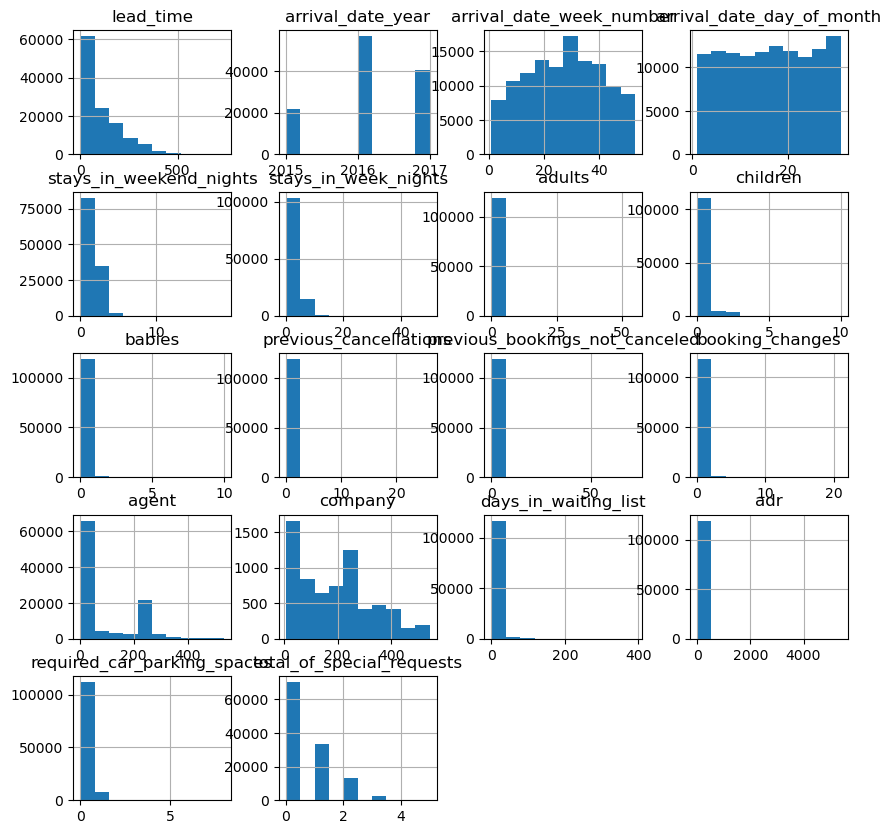

In [620]:
df[numeric_columns].hist(figsize=(10, 10)) 
plt.show() 

### Phân tích hai biến (Bivariate analysis)

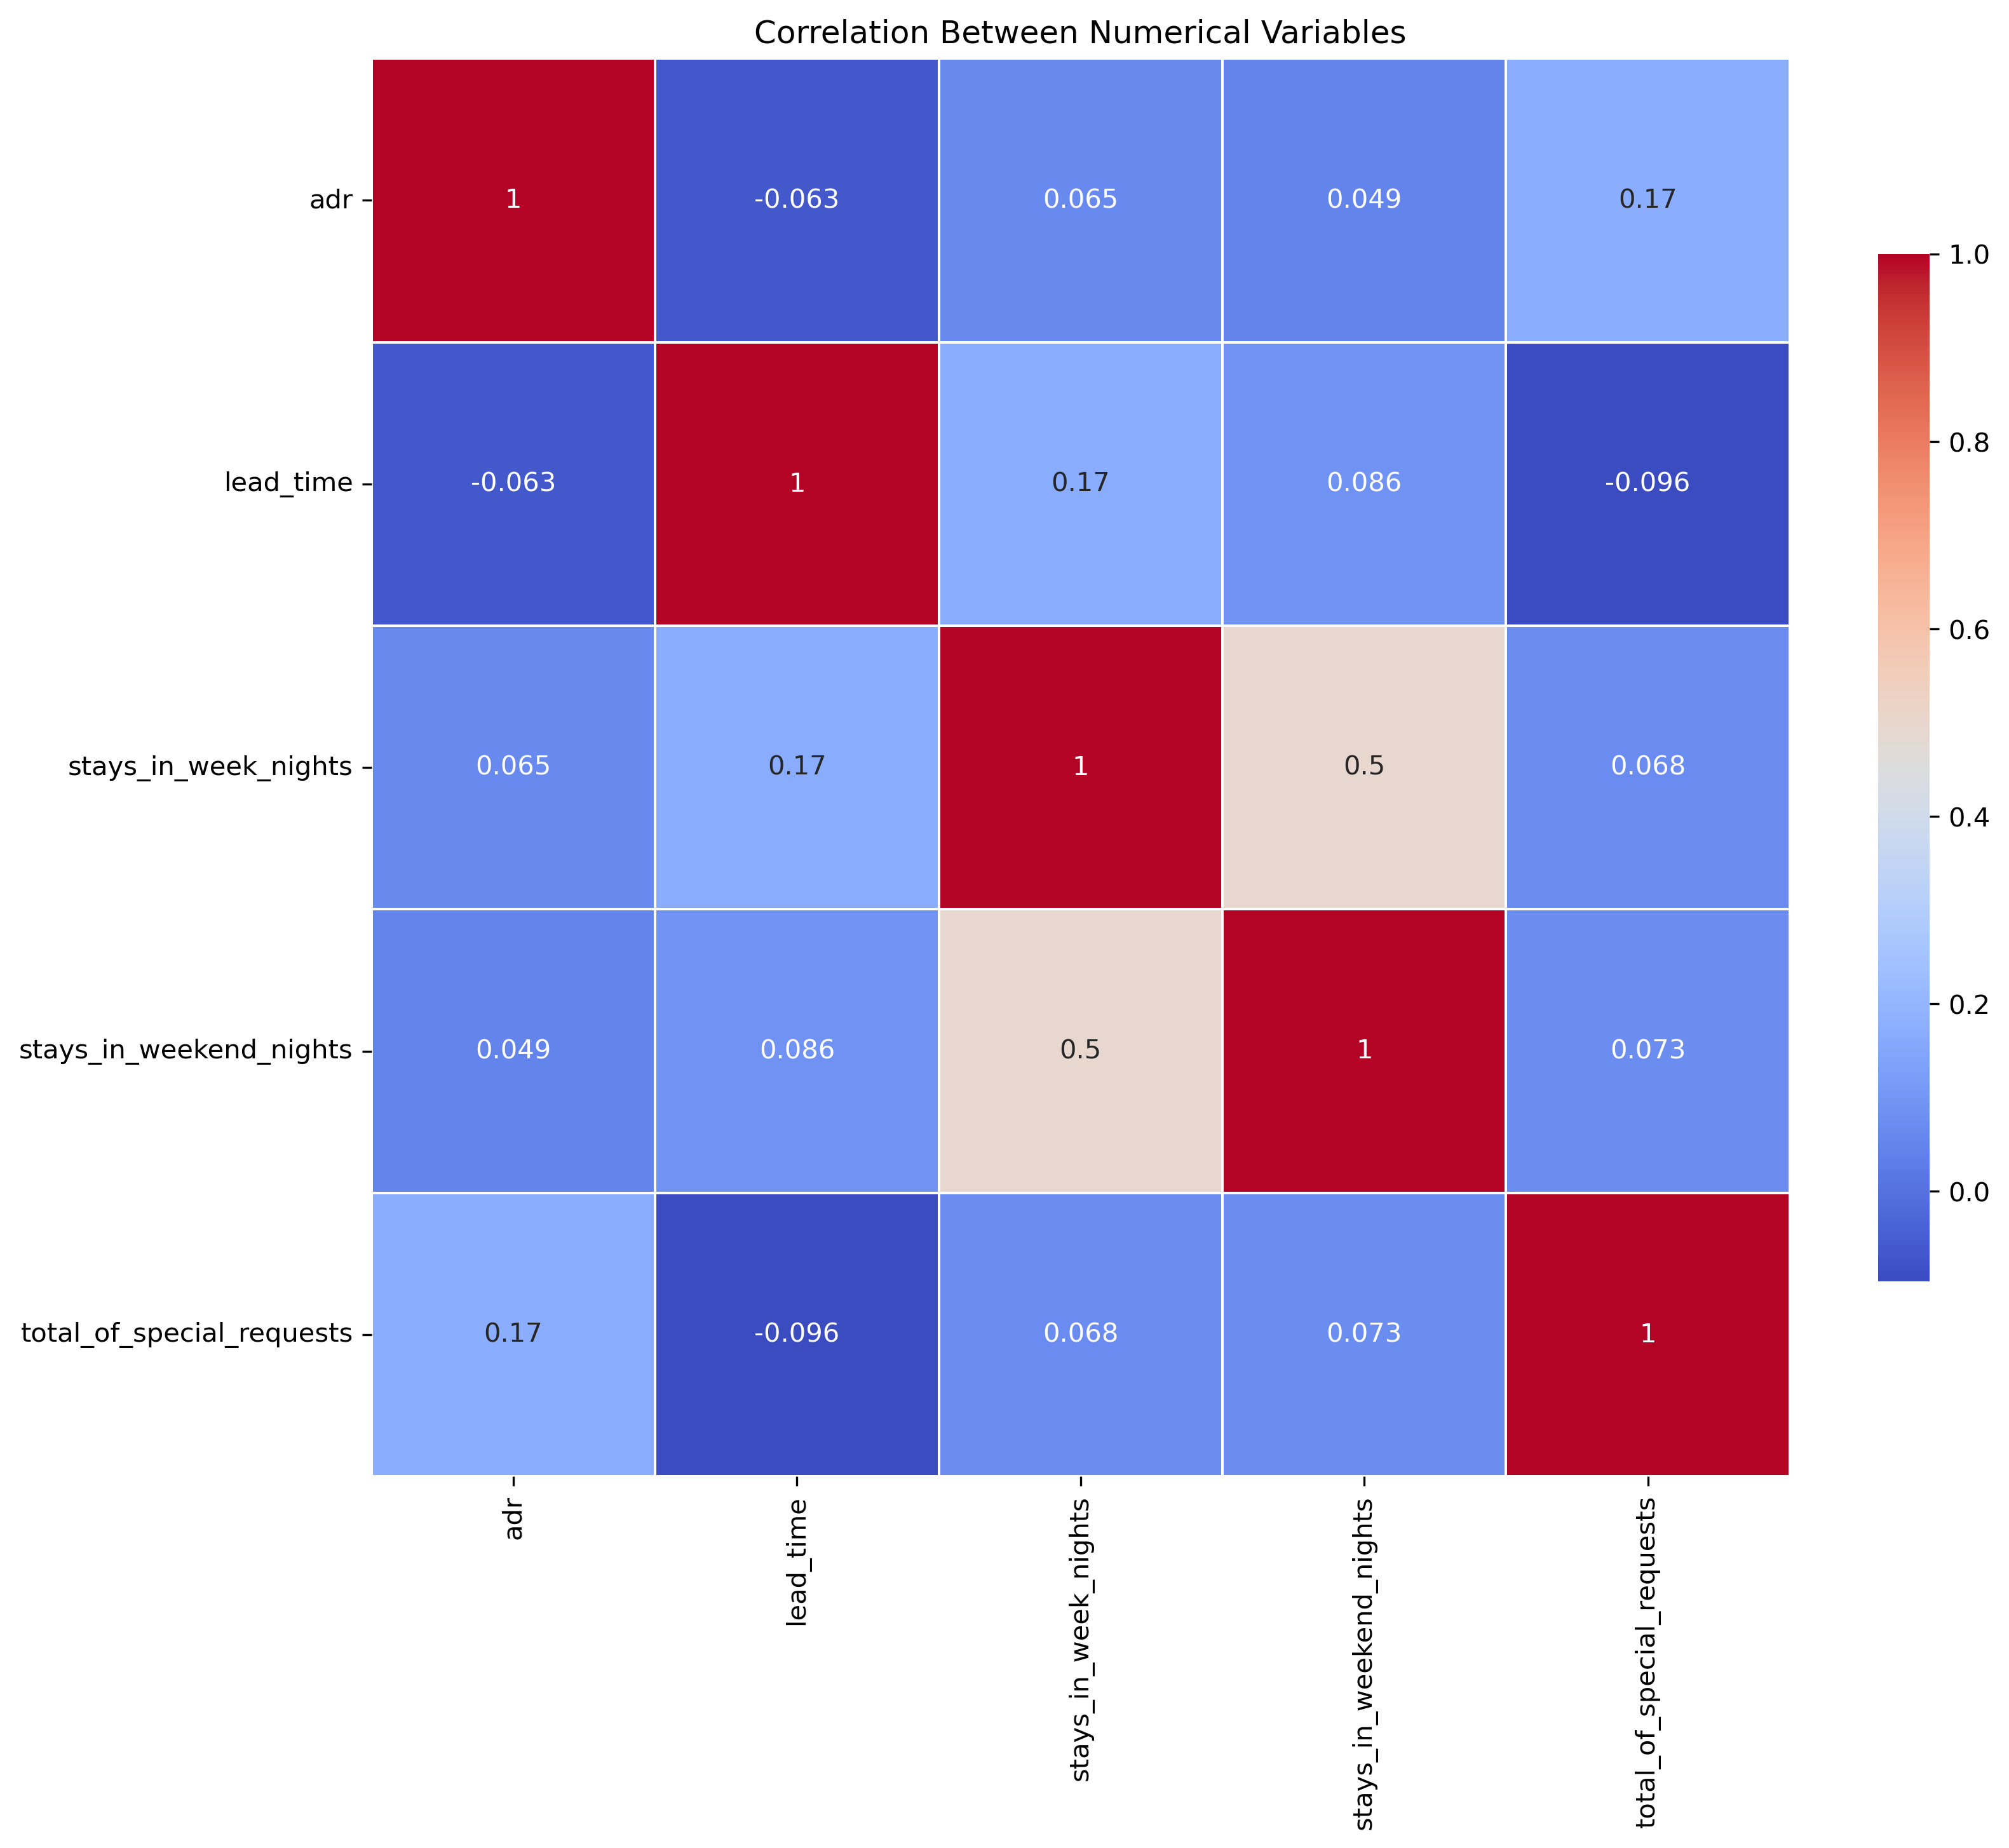

In [621]:

num_cols = ['adr', 'lead_time', 'stays_in_week_nights', 
            'stays_in_weekend_nights', 'total_of_special_requests']
corr = df[num_cols].corr()

plt.figure(figsize=(12, 10), dpi=300)
sns.heatmap(corr, annot=True, cmap='coolwarm', square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Correlation Between Numerical Variables')
plt.show()


##### Kết quả phân tích tương quan cho thấy hầu hết các cặp biến số chỉ có mối quan hệ yếu, nghĩa là hành vi khách không bị chi phối mạnh bởi từng biến riêng lẻ. Tương quan cao nhất là giữa số đêm ở ngày thường và cuối tuần (0.49), cho thấy khách ở lâu thường vào dịp nghỉ cuối tuần. Giá phòng (ADR) có mối liên hệ nhẹ với số yêu cầu đặc biệt (0.17), cho thấy rằng khách hàng phân khúc cao hơn có xu hướng sử dụng thêm dịch vụ – phù hợp để triển khai chiến lược marketing cao cấp.

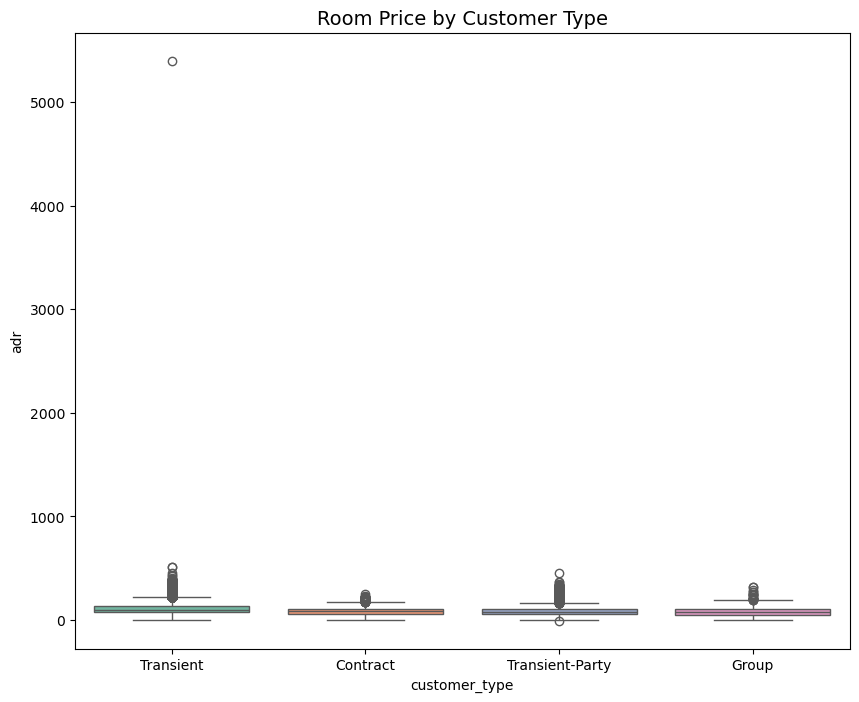

customer_type
Group               83.488579
Transient-Party     86.084253
Contract            87.549637
Transient          107.013621
Name: adr, dtype: float64


In [622]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='customer_type', y='adr', hue='customer_type', data=df, palette='Set2')
plt.title("Room Price by Customer Type", fontsize=14)

plt.show()

df.groupby('customer_type')['adr'].mean().sort_values()

# Hiển thị giá trị trung bình ADR theo loại khách hàng
print(df.groupby('customer_type')['adr'].mean().sort_values())


#### Nhận xét
- Khách đặt phòng đơn lẻ, không theo đoàn, không hợp đồng. Đây là dạng khách phổ biến nhất – khách du lịch, công tác tự book, là phân khúc có khả năng chi trả cao nhất, xuất hiện nhiều booking với ADR cao → là đối tượng quảng cáo, upsell và dịch vụ cao cấp.
- Nhóm đoàn lớn – tour du lịch, hội nghị, sự kiện, công ty du lịch dẫn đoàn và Khách theo hợp đồng công ty, đại lý, doanh nghiệp: khách đi công việc, nhân sự công ty, đại lý gửi khách có ADR thấp → phù hợp khuyến mãi theo số lượng, combo.
- Khách lẻ theo nhóm nhỏ (gia đình, bạn bè) có tiềm năng trung bình, có thể target theo du lịch gia đình, bạn bè.



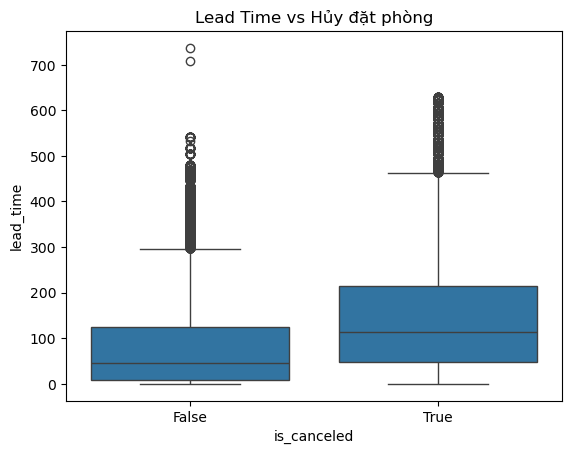

In [623]:
# Mối quan hệ giữa lead_time và is_canceled
data = df
sns.boxplot(x='is_canceled', y='lead_time', data=data)
plt.title("Lead Time vs Hủy đặt phòng")
plt.show()


#### Nhận xét:
Biểu đồ cho thấy lead_time của các đặt phòng bị hủy cao hơn đáng kể so với các đặt phòng giữ nguyên. Điều này chứng minh rằng khách đặt phòng từ rất sớm có xu hướng thay đổi kế hoạch và hủy nhiều hơn. Đây là bằng chứng để khách sạn áp dụng chính sách đặt cọc hoặc ưu đãi giữ phòng cho các booking có lead_time dài.



## Tiền xử lý dữ liệu

### Xử lí missing value

In [624]:
# Xử lý company trước
if 'company' in df.columns:
    missing_pct = df['company'].isnull().sum() / len(df)
    if missing_pct > 0.9:
        print(f"Xóa cột 'company' (thiếu {missing_pct*100:.1f}%)")
        df = df.drop('company', axis=1)
    else:
        df['company'] = df['company'].fillna(0)

# Điền giá trị thiếu - KHÔNG dùng inplace=True
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['agent'] = df['agent'].fillna(0)

# Kiểm tra kết quả
print(f"Tổng giá trị thiếu còn lại: {df.isnull().sum().sum()}")

Xóa cột 'company' (thiếu 94.3%)
Tổng giá trị thiếu còn lại: 0


In [625]:
print(df.isnull().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

### Xử lý dữ liệu trùng lặp


In [626]:
# Xóa trùng lặp
df_cleaned = df.drop_duplicates()

# Kiểm tra lại
print(f"Số hàng trùng còn lại: {df_cleaned.duplicated().sum()}")

# Xem thông tin DataFrame sau khi làm sạch
print(df_cleaned.info())

Số hàng trùng còn lại: 0
<class 'pandas.core.frame.DataFrame'>
Index: 87370 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87370 non-null  object 
 1   is_canceled                     87370 non-null  bool   
 2   lead_time                       87370 non-null  int64  
 3   arrival_date_year               87370 non-null  int64  
 4   arrival_date_month              87370 non-null  object 
 5   arrival_date_week_number        87370 non-null  int64  
 6   arrival_date_day_of_month       87370 non-null  int64  
 7   stays_in_weekend_nights         87370 non-null  int64  
 8   stays_in_week_nights            87370 non-null  int64  
 9   adults                          87370 non-null  int64  
 10  children                        87370 non-null  float64
 11  babies                          87370 non-null  int64  
 12  meal       

In [627]:
df_cleaned = df.drop_duplicates(keep='first')
print(f"Số hàng trước khi xóa trùng lặp: {len(df)} hàng")
print(f"Số hàng sau khi xóa trùng lặp: {len(df_cleaned)} hàng")
print(f"Đã xóa: {len(df) - len(df_cleaned)} hàng")

Số hàng trước khi xóa trùng lặp: 119390 hàng
Số hàng sau khi xóa trùng lặp: 87370 hàng
Đã xóa: 32020 hàng


### Xử lý outlier


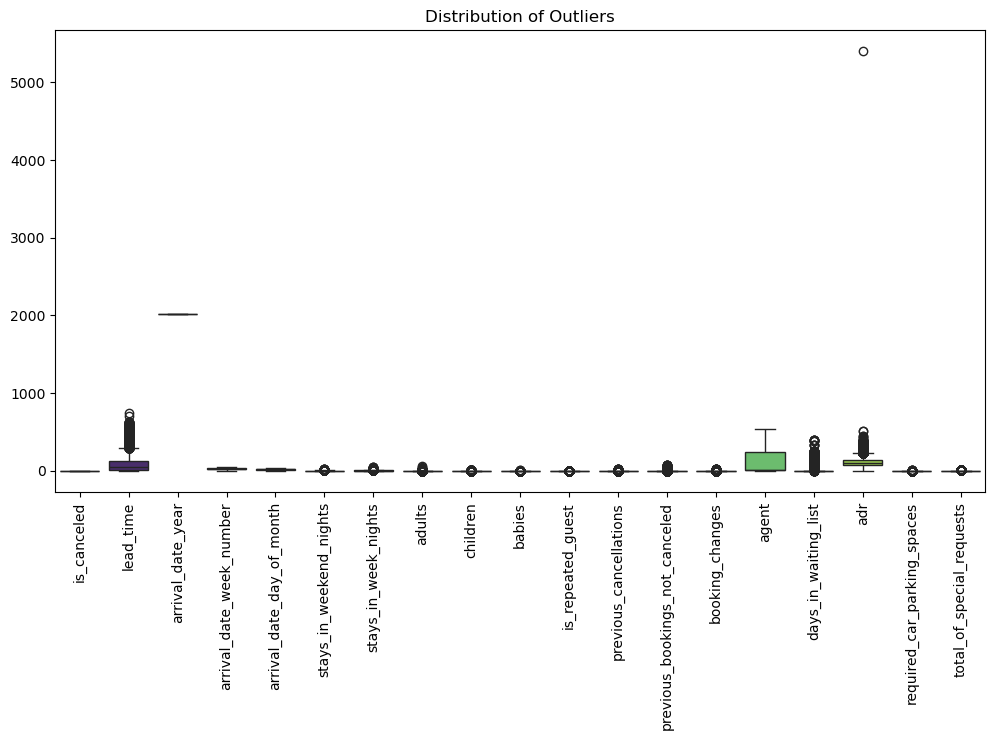

In [628]:
#BOX PLOT TRƯỚC KHI XỬ LÍ 
plt.figure(figsize=(12,6))
sns.boxplot(data=df_cleaned, palette='viridis')
plt.title('Distribution of Outliers')
plt.xticks(rotation=90)
plt.show()

In [629]:
print("Thống kê mô tả của dữ liệu trước khi xử lý outlier:")
print(df_cleaned.describe())

Thống kê mô tả của dữ liệu trước khi xử lý outlier:
          lead_time  arrival_date_year  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights        adults      children  \
count  87370.000000       87370.000000              87370.000000               87370.000000             87370.000000          87370.000000  87370.000000  87370.000000   
mean      79.911686        2016.210290                 26.839533                  15.815360                 1.005448              2.625798      1.875953      0.138675   
std       86.056471           0.686116                 13.673204                   8.834842                 1.031974              2.053692      0.626473      0.455933   
min        0.000000        2015.000000                  1.000000                   1.000000                 0.000000              0.000000      0.000000      0.000000   
25%       11.000000        2016.000000                 16.000000                   8.000000       

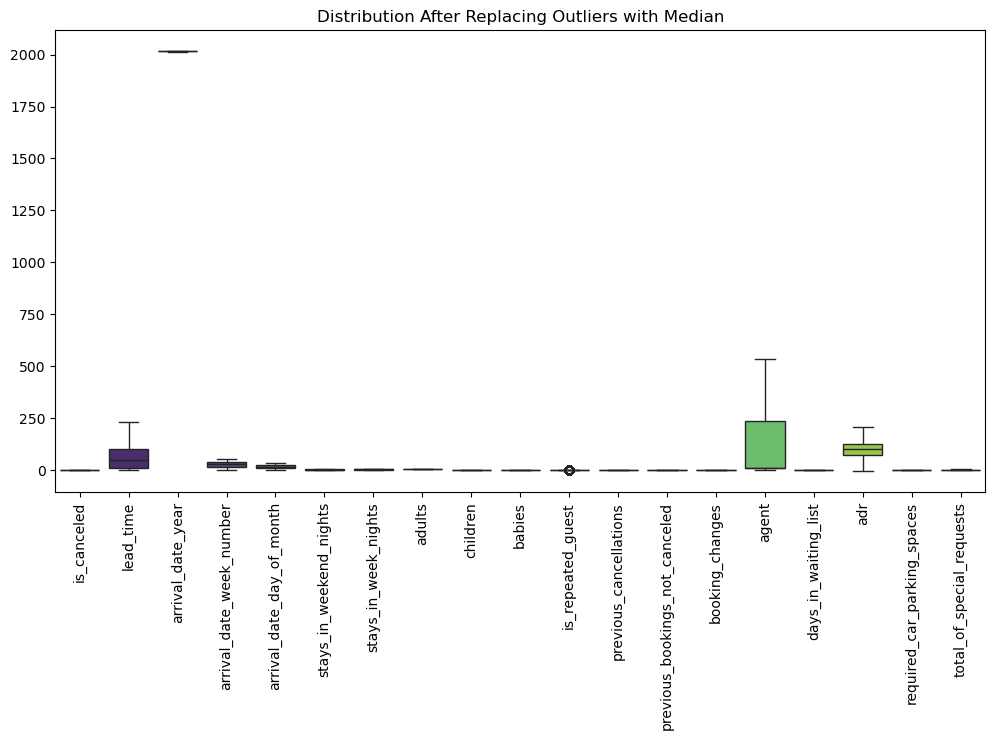

Thống kê mô tả sau khi thay thế outliers:
          lead_time  arrival_date_year  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights   adults  children   babies  \
count  87370.000000       87370.000000              87370.000000               87370.000000             87370.000000          87370.000000  87370.0   87370.0  87370.0   
mean      62.941021        2016.210290                 26.839533                  15.815360                 0.989253              2.366144      2.0       0.0      0.0   
std       60.972946           0.686116                 13.673204                   8.834842                 0.973871              1.482141      0.0       0.0      0.0   
min        0.000000        2015.000000                  1.000000                   1.000000                 0.000000              0.000000      2.0       0.0      0.0   
25%       11.000000        2016.000000                 16.000000                   8.000000                 

In [630]:

# --- HÀM THAY OUTLIER BẰNG TRUNG VỊ ---
def replace_outliers_with_median(df):
    df_cleaned = df.copy()  # tránh sửa trực tiếp dữ liệu gốc
    for column in df_cleaned.select_dtypes(include=[np.number]).columns:
        while True:
            q1 = df_cleaned[column].quantile(0.25)
            q3 = df_cleaned[column].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            
            # Xác định outlier
            outliers = (df_cleaned[column] < lower_bound) | (df_cleaned[column] > upper_bound)
            
            # Nếu không còn outlier thì thoát vòng lặp
            if not outliers.any():
                break
            
            # Thay thế bằng trung vị
            median = df_cleaned[column].median()
            df_cleaned.loc[outliers, column] = median
    return df_cleaned

# --- GỌI HÀM ---
df_no_outlier = replace_outliers_with_median(df_cleaned)

# --- XÁC NHẬN KẾT QUẢ ---
plt.figure(figsize=(12,6))
sns.boxplot(data=df_no_outlier, palette='viridis')
plt.title('Distribution After Replacing Outliers with Median')
plt.xticks(rotation=90)
plt.show()

# --- THỐNG KÊ TÓM TẮT SAU KHI XỬ LÝ ---
print("Thống kê mô tả sau khi thay thế outliers:")
print(df_no_outlier.describe())


### Xử lý ngoại lệ và giá trị bất thường trong dữ liệu đặt phòng:

- **Stays in Week Nights:** Quan sát có giá trị >50 đêm. Xử lý bằng cách giới hạn tối đa 30 đêm và có thể phân loại ngắn/trung/dài.  
- **Stays in Weekend Nights:** Quan sát có giá trị >17 đêm. Giới hạn tối đa 10 đêm.  
- **Adults, Children, Babies:** Quan sát có giá trị bất thường (adults >50, children >10). Lọc các giá trị không hợp lý (adults ≤10, children ≤10, babies ≤5) và điền giá trị thiếu (children = median, babies = 0).  
- **Previous Cancellations & Previous Bookings Not Canceled:** Quan sát có giá trị >20. Giới hạn tối đa 10, đồng thời phân tích các trường hợp hủy/đặt nhiều.  
- **Booking Changes:** Một số booking có >10 thay đổi. Giới hạn tối đa 5 và kiểm tra nguyên nhân các booking thay đổi nhiều.  
- **Days in Waiting List:** Quan sát có giá trị >300 ngày. Giới hạn tối đa 200 ngày và phân loại ngắn/trung/dài cho phân tích.

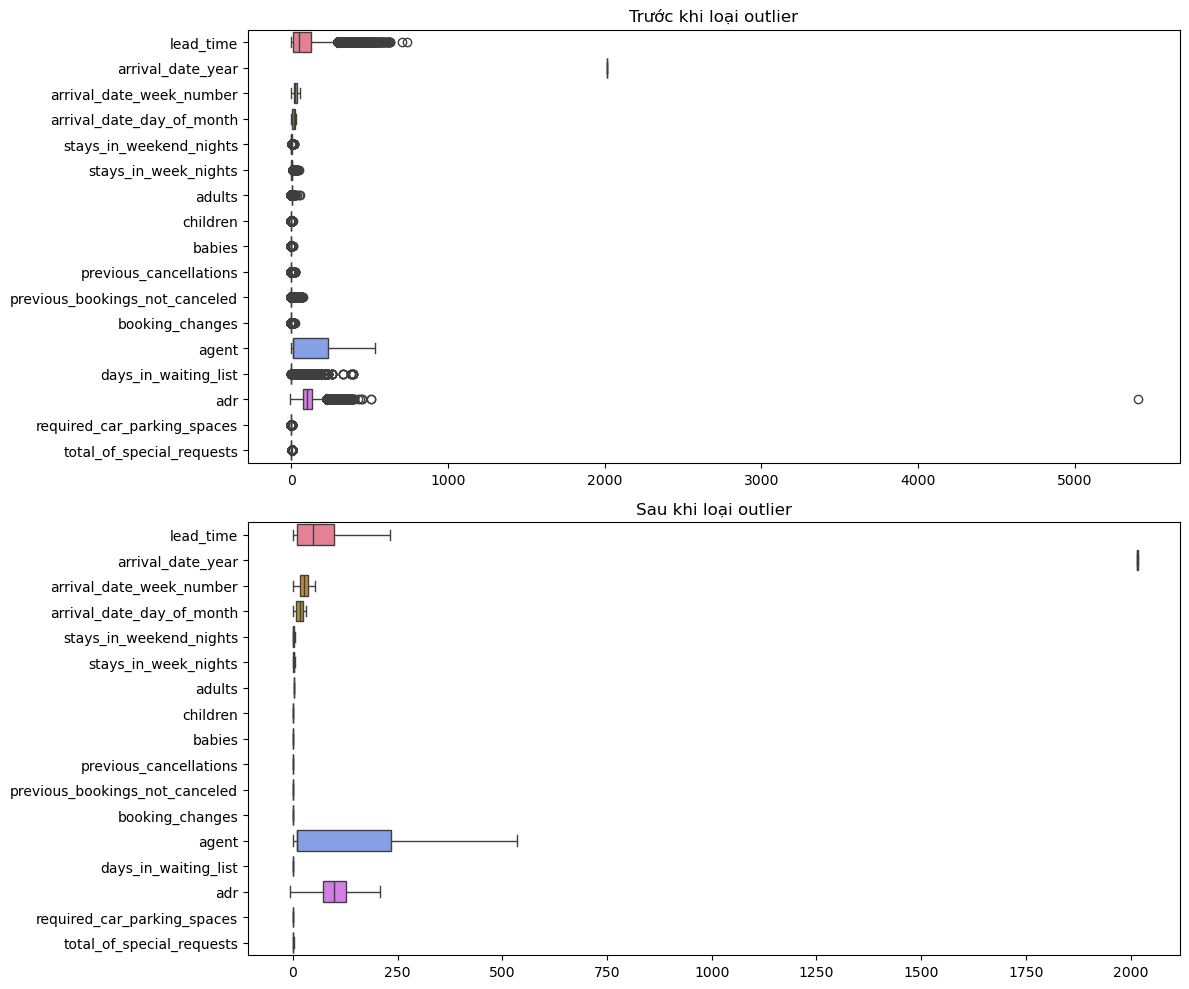

In [631]:
# Trực quan lại trước và sau xử lý outlier
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12,10))
plt.subplot(2,1,1)
sns.boxplot(data=df_cleaned[numeric_cols], orient='h')
plt.title("Trước khi loại outlier")

plt.subplot(2,1,2)
sns.boxplot(data=df_no_outlier[numeric_cols], orient='h')
plt.title("Sau khi loại outlier")

plt.tight_layout()
plt.show()


In [632]:
print("Kiểm tra kích thước và các giá trị sau xử lý:")
print(df_no_outlier.shape)
print(df_no_outlier.describe())


Kiểm tra kích thước và các giá trị sau xử lý:
(87370, 31)
          lead_time  arrival_date_year  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights   adults  children   babies  \
count  87370.000000       87370.000000              87370.000000               87370.000000             87370.000000          87370.000000  87370.0   87370.0  87370.0   
mean      62.941021        2016.210290                 26.839533                  15.815360                 0.989253              2.366144      2.0       0.0      0.0   
std       60.972946           0.686116                 13.673204                   8.834842                 0.973871              1.482141      0.0       0.0      0.0   
min        0.000000        2015.000000                  1.000000                   1.000000                 0.000000              0.000000      2.0       0.0      0.0   
25%       11.000000        2016.000000                 16.000000                   8.000000 

##### 1. Tách chi phí bữa ăn ra khỏi ADR để xác định giá phòng/đêm và số đêm khách ở

In [633]:
# 1. % chi phí ăn theo loại meal
meal_map = {
    'BB': 0.12,  # bed & breakfast
    'HB': 0.30,  # half board
    'FB': 0.45,  # full board
    'SC': 0.00   # self catering (không ăn)
}

df_no_outlier['meal_pct'] = df_no_outlier['meal'].map(meal_map).fillna(0)

# 2. Tổng số đêm khách ở
df_no_outlier['total_nights'] = df_no_outlier['stays_in_weekend_nights'] + df_no_outlier['stays_in_week_nights']

# 3. GIÁ ĐẶT PHÒNG/ĐÊM (room price per night)
df_no_outlier['room_price_per_night'] = df_no_outlier['adr'] * (1 - df_no_outlier['meal_pct'])

# 4. TỔNG GIÁ ĐẶT PHÒNG CHO CẢ KỲ Ở
df_no_outlier['room_price_total'] = df_no_outlier['room_price_per_night'] * df_no_outlier['total_nights']

# Xem thử 10 dòng đầu
df_no_outlier[['adr','meal','total_nights','room_price_per_night','room_price_total']].head(10)


,adr,meal,total_nights,room_price_per_night,room_price_total
0,0.0,BB,0,0.00,0.00
1,0.0,BB,0,0.00,0.00
2,75.0,BB,1,66.00,66.00
3,75.0,BB,1,66.00,66.00
4,98.0,BB,2,86.24,172.48
6,107.0,BB,2,94.16,188.32
7,103.0,FB,2,56.65,113.30
8,82.0,BB,3,72.16,216.48
9,105.5,HB,3,73.85,221.55
10,123.0,BB,4,108.24,432.96


Biến `adr` (Average Daily Rate) trong bộ dữ liệu thể hiện mức giá trung bình mà khách phải trả cho **mỗi phòng trên mỗi đêm**. Tuy nhiên, giá trị này thường bao gồm nhiều thành phần chi phí khác nhau như: tiền phòng, tiền ăn sáng, ăn trưa, ăn tối hoặc các gói dịch vụ đi kèm. 

Để phục vụ cho mục tiêu nghiên cứu tập trung vào **giá đặt phòng**, cần tách riêng phần chi phí liên quan đến **bữa ăn** ra khỏi `adr`. Dữ liệu cung cấp biến `meal` thể hiện loại hình dịch vụ ăn uống mà khách lựa chọn, bao gồm các giá trị chính:

- `SC` (Self Catering): không bao gồm bữa ăn.
- `BB` (Bed & Breakfast): bao gồm ăn sáng.
- `HB` (Half Board): bao gồm ăn sáng và một bữa chính (trưa hoặc tối).
- `FB` (Full Board): bao gồm đầy đủ 3 bữa.

Dựa trên thông lệ thực tế trong ngành khách sạn và các ước lượng mang tính tham khảo, luận văn giả định một tỷ lệ chi phí bữa ăn trong tổng `adr` như sau:

- `BB`: chi phí bữa ăn chiếm khoảng 12% tổng `adr`.
- `HB`: chi phí bữa ăn chiếm khoảng 30% tổng `adr`.
- `FB`: chi phí bữa ăn chiếm khoảng 45% tổng `adr`.
- `SC`: không bao gồm bữa ăn nên tỷ lệ là 0%.

Từ đó xây dựng biến mới `meal_pct` là tỷ lệ phần trăm chi phí ăn uống so với `adr`. Phần ăn uống ước tính trên mỗi đêm được tính bằng:
  
> `food_cost_per_night = adr × meal_pct`

Việc xác định được tỷ trọng chi phí ăn uống giúp tách riêng được phần **giá phòng thuần** khỏi tổng giá mà khách đã trả.

Sau khi đã tách được phần chi phí ăn uống khỏi `adr`, giá phòng thuần trên mỗi đêm được xác định bằng cách trừ đi phần chi phí bữa ăn:

> `room_price_per_night = adr × (1 − meal_pct)`

Trong đó:
- `adr` là giá trung bình mỗi phòng mỗi đêm ban đầu.
- `meal_pct` là tỷ lệ chi phí ăn uống ước tính theo từng loại `meal`.

Cách làm này dựa trên giả định rằng `adr` được cấu thành chủ yếu từ hai nhóm chi phí chính: **tiền phòng** và **tiền bữa ăn** (các chi phí dịch vụ khác được xem là nhỏ hoặc phân bổ đều). Với những đặt phòng thuộc loại `SC` (không bao gồm bữa ăn), ta có `meal_pct = 0`, do đó:

> `room_price_per_night ≈ adr`

Điều này phù hợp với trực giác: khi khách không sử dụng dịch vụ ăn uống, giá trung bình họ trả cho mỗi phòng mỗi đêm gần như chính là **giá phòng thuần**.

Biến `room_price_per_night` là biến trung tâm của đề tài, vì nó đại diện cho **giá đặt phòng/đêm sau khi đã loại bỏ ảnh hưởng của gói ăn uống**.

##### 2. Tính tổng số đêm lưu trú của khách hàng

Để xác định tổng số tiền phòng mà khách phải trả cho **toàn bộ kỳ lưu trú**, cần biết khách ở bao nhiêu đêm. Bộ dữ liệu đã tách thời gian lưu trú thành hai biến:

- `stays_in_week_nights`: số đêm trong tuần (thứ 2–thứ 6).
- `stays_in_weekend_nights`: số đêm cuối tuần (thứ 7, chủ nhật).

Tổng số đêm lưu trú được tính đơn giản bằng:

> `total_nights = stays_in_week_nights + stays_in_weekend_nights`

Biến `total_nights` là cơ sở để nhân với **giá phòng/đêm** (sau khi đã tách bữa ăn) nhằm tính ra **tổng giá đặt phòng** cho toàn bộ kỳ ở của từng booking. Biến này cũng có thể dùng để phân tích mối quan hệ giữa độ dài lưu trú và mức giá/phân khúc khách hàng.

In [634]:
# Kiểm tra dữ liệu gốc
df_no_outlier.groupby('customer_type')['room_price_per_night'].mean()
df_no_outlier.groupby('reserved_room_type')['room_price_per_night'].mean()
df_no_outlier[['total_nights','room_price_total']].corr()


,total_nights,room_price_total
total_nights,1.000000,0.775177
room_price_total,0.775177,1.000000


Ý nghĩa của hệ số tương quan 0.748438

Hệ số tương quan 0.748 (gần với 0.75) là mức tương quan dương mạnh.

Điều này cho thấy khi khách lưu trú số đêm càng nhiều, thì tổng giá đặt phòng tăng lên đáng kể, và mối quan hệ này là tuyến tính khá rõ ràng.

Đây là kết quả hoàn toàn hợp lý về mặt nghiệp vụ: tổng chi phí phòng = giá phòng/đêm × số đêm; do đó hai yếu tố này phải có quan hệ tương đối mạnh.

# Kết luận cho phần này:

Biến room_price_total được xây dựng là hợp lý vì nó phản ánh đúng bản chất của hành vi đặt phòng.

Độ dài kỳ lưu trú (total_nights) là một trong các yếu tố quan trọng nhất ảnh hưởng tới tổng giá trị của booking.

Phân tích tương quan giúp xác nhận rằng phương pháp tách giá phòng của luận văn là nhất quán và phù hợp để sử dụng ở các phần phân tích tiếp theo (mô hình dự đoán, phân khúc khách hàng, phân tích doanh thu…).

In [635]:
print(df_no_outlier.columns)


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'meal_pct', 'total_nights', 'room_price_per_night',
       'room_price_total'],
      dtype='object')


In [636]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler

data_model = df_no_outlier.copy()

# Chọn các cột numeric và categorical
numeric_cols = [
    'lead_time', 'total_nights',
    'adults', 'children', 'babies', 'adr',
    'room_price_total', 'booking_changes',
    'days_in_waiting_list',
    'total_of_special_requests',
    'previous_cancellations',
    'previous_bookings_not_canceled',
]


categorical_cols = [
    'hotel', 
    'is_repeated_guest',
]
# --- Dữ liệu hiển thị giữ giá trị thực ---
df_display = data_model[numeric_cols + categorical_cols].copy()
# Tạo dataframe gồm numeric và categorical để chạy mô hình
df_model = data_model[numeric_cols + categorical_cols].copy()


In [637]:
print(df_display.columns)


Index(['lead_time', 'total_nights', 'adults', 'children', 'babies', 'adr', 'room_price_total', 'booking_changes', 'days_in_waiting_list', 'total_of_special_requests',
       'previous_cancellations', 'previous_bookings_not_canceled', 'hotel', 'is_repeated_guest'],
      dtype='object')


In [638]:
print(df_model.columns)


Index(['lead_time', 'total_nights', 'adults', 'children', 'babies', 'adr', 'room_price_total', 'booking_changes', 'days_in_waiting_list', 'total_of_special_requests',
       'previous_cancellations', 'previous_bookings_not_canceled', 'hotel', 'is_repeated_guest'],
      dtype='object')


In [639]:

# Tạo OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop=None)

# Áp dụng encoder
df_encoded = pd.DataFrame(
    ohe.fit_transform(df_model[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols),
    index=df_model.index
)

# Hiển thị thử 5 dòng đầu
from IPython.display import display, HTML
display(HTML(
    df_encoded.head(5).to_html(max_cols=None)
    .replace('<table', '<table style="overflow-x:auto; display:block;"')
))


,hotel_City Hotel,hotel_Resort Hotel,is_repeated_guest_False,is_repeated_guest_True
0,0.0,1.0,1.0,0.0
1,0.0,1.0,1.0,0.0
2,0.0,1.0,1.0,0.0
3,0.0,1.0,1.0,0.0
4,0.0,1.0,1.0,0.0


In [640]:


scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_model[numeric_cols])  # Chỉ scale 13 cột numeric

# Ghi đè cột số đã scale
df_model[numeric_cols] = scaled_data



In [641]:
# Lưu CSV
df_model.to_csv('hotel_booking_cleaned.csv', index=False)

In [642]:
from sklearn.decomposition import PCA

# --- Gộp numeric + onehot để chạy PCA ---
X_for_pca = pd.concat([
    df_model[numeric_cols],
    df_encoded  # đã OHE từ categorical_cols
], axis=1)

# --- PCA giữ lại 90% variance ---
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_for_pca)

print("Số lượng components sau PCA:", X_pca.shape[1])


Số lượng components sau PCA: 4


#### Phân 3 cụm tổng quan

In [643]:
from sklearn.cluster import KMeans, Birch, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

algorithms = {
    'KMeans': KMeans(n_clusters=3, random_state=42, n_init=50),
    'Birch': Birch(n_clusters=3),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=10)
}

results = {}

for name, algo in algorithms.items():
    try:
        # Fit trên PCA
        labels = algo.fit_predict(X_pca)

        # Với DBSCAN bỏ nhãn -1
        if name == 'DBSCAN':
            mask = labels != -1
            X_eval = X_pca[mask]
            y_eval = labels[mask]
            inertia = None
        else:
            X_eval = X_pca
            y_eval = labels
            inertia = getattr(algo, 'inertia_', None)

        sil_score = silhouette_score(X_eval, y_eval)
        ch_score  = calinski_harabasz_score(X_eval, y_eval)
        db_score  = davies_bouldin_score(X_eval, y_eval)

        results[name] = {
            'Inertia': inertia,
            'Silhouette': sil_score,
            'Calinski-Harabasz': ch_score,
            'Davies-Bouldin': db_score
        }

    except Exception as e:
        print(f"{name} lỗi: {e}")

# In bảng
pd.DataFrame(results).T


,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
KMeans,266303.002682,0.228191,28374.072811,1.479417
Birch,NaN,0.121151,12092.761332,2.162293
DBSCAN,NaN,0.115440,5755.648249,1.714350


1. KMeans cho kết quả nổi trội nhất

Chỉ số Silhouette của KMeans (0.190158) là cao nhất, cho thấy cấu trúc cụm được phân tách tốt hơn so với hai thuật toán còn lại.

Chỉ số Calinski-Harabasz cũng đạt giá trị lớn nhất (20983.196052), thể hiện các cụm được hình thành rõ ràng và có sự khác biệt đáng kể giữa các nhóm.

Chỉ số Davies-Bouldin là 1.736474, không phải thấp nhất, nhưng vẫn nằm trong mức chấp nhận được.

Inertia chỉ được sử dụng cho KMeans, vì đây là chỉ số đặc thù của thuật toán này.

Tổng hợp các yếu tố trên cho thấy KMeans là thuật toán mang lại chất lượng phân cụm tốt nhất.

2. Birch cho kết quả trung bình

Silhouette (0.156321) thấp hơn KMeans, thể hiện cấu trúc cụm kém tách biệt hơn.

Chỉ số Calinski-Harabasz (16051.796640) giảm đáng kể, cho thấy độ gọn và độ phân tách giữa các cụm yếu hơn.

Davies-Bouldin (1.892848) là cao nhất trong ba thuật toán, cho thấy các cụm bị chồng lấn nhiều nhất.

Nhìn chung, Birch hoạt động được nhưng chất lượng phân cụm không bằng KMeans.

3. DBSCAN cho kết quả không phù hợp

Silhouette thấp nhất (0.133094), cho thấy cụm hình thành không rõ ràng.

Calinski-Harabasz rất thấp (617.308049), phản ánh việc phân cụm kém hiệu quả trên dữ liệu này.

Mặc dù Davies-Bouldin đạt giá trị thấp nhất (1.227953), điều này không đủ để cân bằng với các chỉ số khác vốn cho thấy chất lượng cụm kém.

DBSCAN thường phù hợp với dữ liệu có dạng phân bố theo mật độ. Trong trường hợp này, dữ liệu không có cấu trúc phù hợp nên DBSCAN hoạt động không tốt.

Kết luận chung

Trong ba thuật toán được đánh giá, KMeans mang lại kết quả tốt nhất và phù hợp nhất với bộ dữ liệu, vì tạo ra các cụm vừa rõ ràng, vừa ổn định theo nhiều chỉ số. Birch có thể chấp nhận được nhưng kém hơn. DBSCAN không phù hợp cho cấu trúc dữ liệu hiện tại.

=== Ví dụ 5 dòng đầu sau khi gán tên cụm ===


,Cụm,Tên Cụm
0,0,Khách chi tiêu thấp
1,0,Khách chi tiêu thấp
2,0,Khách chi tiêu thấp
3,0,Khách chi tiêu thấp
4,1,Khách chi tiêu trung bình



===== TÓM TẮT ĐẶC TRƯNG TỪNG CỤM KHÁCH HÀNG =====


,adr_mean,adr_count,lead_time_mean,total_of_special_requests_mean,hotel_City Hotel,hotel_Resort Hotel,is_repeated_guest_False,is_repeated_guest_True
Tên Cụm,,,,,,,,
Khách chi tiêu cao,117.22,24608,104.95,0.48,0.50,0.50,0.99,0.01
Khách chi tiêu thấp,80.03,37418,38.83,0.15,0.59,0.41,0.93,0.07
Khách chi tiêu trung bình,111.05,25344,57.75,1.38,0.76,0.24,0.98,0.02


C:\Users\DELL\AppData\Local\Temp\ipykernel_12292\3248200319.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_12292\3248200319.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


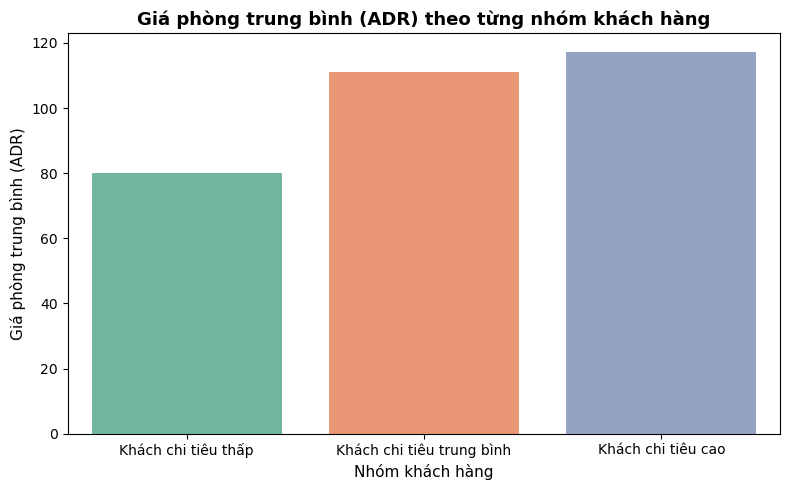

In [644]:
# --- Chọn số cụm tối ưu ---
optimal_k = 3  # dựa trên biểu đồ hoặc các chỉ số silhouette, CH, DB

# --- 1) Copy dữ liệu để chạy KMeans ---
model_dt = df_model.copy()

# --- 2) Chạy KMeans ---
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=50)
model_dt['Cụm'] = kmeans.fit_predict(X_pca)

# --- 3) Gán tên cụm dựa trên room_price_total ---
cluster_stats = model_dt.groupby('Cụm')[['adr','room_price_total','total_nights']].mean()
low_q, high_q = cluster_stats['room_price_total'].quantile([0.33, 0.66])

ten_cum = {}
for cum_id, row in cluster_stats.iterrows():
    if row['room_price_total'] > high_q:
        ten_cum[cum_id] = 'Khách chi tiêu cao'
    elif row['room_price_total'] < low_q:
        ten_cum[cum_id] = 'Khách chi tiêu thấp'
    else:
        ten_cum[cum_id] = 'Khách chi tiêu trung bình'

model_dt['Tên Cụm'] = model_dt['Cụm'].map(ten_cum)
df_display['Cụm'] = model_dt['Cụm']
df_display['Tên Cụm'] = model_dt['Tên Cụm']

print("=== Ví dụ 5 dòng đầu sau khi gán tên cụm ===")
display(df_display[['Cụm','Tên Cụm']].head())

# --- 4) Tóm tắt đặc trưng từng cụm (numeric + one-hot) ---
# Chỉ lấy các cột numeric thực sự có trong df_display
cols_display_numeric = [
    'adr', 'lead_time', 'total_of_special_requests'
]
cols_exist = [c for c in cols_display_numeric if c in df_display.columns]

# Trung bình numeric
agg_numeric = {c: 'mean' for c in cols_exist if c != 'adr'}
if 'adr' in cols_exist:
    agg_numeric['adr'] = ['mean','count']

numeric_summary = df_display.groupby('Tên Cụm').agg(agg_numeric)

# Trung bình one-hot
onehot_summary = df_encoded.groupby(model_dt['Tên Cụm']).mean()

# Gộp numeric + one-hot
cluster_summary = pd.concat([numeric_summary, onehot_summary], axis=1).round(2)

# Flatten MultiIndex
cluster_summary.columns = [
    f"{col[0]}_{col[1]}" if isinstance(col, tuple) else col
    for col in cluster_summary.columns
]

# Sắp xếp cột chính (chỉ những cột tồn tại)
main_cols = ['adr_mean','adr_count','lead_time_mean','total_of_special_requests_mean']
main_cols_exist = [c for c in main_cols if c in cluster_summary.columns]
final_cols = main_cols_exist + [c for c in cluster_summary.columns if c not in main_cols_exist]
cluster_summary = cluster_summary[final_cols]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

print("\n===== TÓM TẮT ĐẶC TRƯNG TỪNG CỤM KHÁCH HÀNG =====")
display(cluster_summary)

# --- 5) Biểu đồ ADR theo nhóm khách ---
import seaborn as sns
import matplotlib.pyplot as plt

if 'adr' in cols_exist:
    palette_colors = {
        'Khách chi tiêu cao': '#8da0cb',
        'Khách chi tiêu thấp': '#66c2a5',
        'Khách chi tiêu trung bình': '#fc8d62'
    }

    plt.figure(figsize=(8,5))
    sns.barplot(
        x='Tên Cụm',
        y='adr',
        data=df_display,
        palette=palette_colors,
        ci=None
    )
    plt.title("Giá phòng trung bình (ADR) theo từng nhóm khách hàng", fontsize=13, fontweight='bold')
    plt.xlabel("Nhóm khách hàng", fontsize=11)
    plt.ylabel("Giá phòng trung bình (ADR)", fontsize=11)
    plt.xticks(rotation=0, ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()


In [645]:
optimal_k = 3  # dựa trên biểu đồ

# --- Bước 1: Copy dữ liệu ---
model_dt = df_model.copy()

# --- Bước 2: Chạy KMeans ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
model_dt['Cụm'] = kmeans.fit_predict(X_pca)


# --- Bước 3: Tính trung bình từng cụm ---
cluster_summary = model_dt.groupby('Cụm')[['adr','room_price_total', 'total_nights']].mean()
print("=== TÓM TẮT ĐẶC TRƯNG MỖI CỤM ===")
print(cluster_summary)

# --- Bước 4: Tự động gán tên cụm ---
ten_cum = {}

# Ngưỡng phân 3 nhóm
low_q  = cluster_summary['room_price_total'].quantile(0.33)
high_q = cluster_summary['room_price_total'].quantile(0.66)
median_stay = cluster_summary['total_nights'].median()

for cum_id in cluster_summary.index:

    price_mean  = cluster_summary.loc[cum_id, 'room_price_total']
    nights_mean = cluster_summary.loc[cum_id, 'total_nights']
    adr_mean    = cluster_summary.loc[cum_id, 'adr']

    # ---- 1. Khách chi tiêu cao ----
    if price_mean > high_q:
        ten_cum[cum_id] = "Khách chi tiêu cao"

    # ---- 2. Khách tiết kiệm ----
    elif price_mean < low_q:
        ten_cum[cum_id] = "Khách chi tiêu thấp"

    # ---- 3. Khách tầm trung ----
    else:
        ten_cum[cum_id] = "Khách chi tiêu trung bình"

# Gán tên cụm vào DataFrame
model_dt['Tên Cụm'] = model_dt['Cụm'].map(ten_cum)
# --- Gán nhãn cụm vào dữ liệu hiển thị ---
df_display['Cụm'] = model_dt['Cụm']
df_display['Tên Cụm'] = model_dt['Tên Cụm']

# --- Bước 5: Kiểm tra kết quả ---
print("\n=== Ví dụ 5 dòng đầu sau khi gán tên cụm ===")
print(df_display[['Cụm', 'Tên Cụm']].head())


=== TÓM TẮT ĐẶC TRƯNG MỖI CỤM ===
          adr  room_price_total  total_nights
Cụm                                          
0   -0.467007         -0.651687     -0.558102
1    0.276951         -0.135188     -0.279992
2    0.424879          1.130162      1.136995

=== Ví dụ 5 dòng đầu sau khi gán tên cụm ===
   Cụm                    Tên Cụm
0    0        Khách chi tiêu thấp
1    0        Khách chi tiêu thấp
2    0        Khách chi tiêu thấp
3    0        Khách chi tiêu thấp
4    1  Khách chi tiêu trung bình


- Khách chi tiêu cao
    - ADR trung bình: 109.88 → chi tiêu cao nhất.
    - Lead time: 95.39 ngày → đặt trước lâu.
    - Số đêm lưu trú: 5.84 đêm (tổng tuần + cuối tuần) → lưu trú dài hơn trung bình.
    - Loại khách: chủ yếu Transient, ít Contract/Group.
    - Kênh đặt: Online TA chiếm 60%, Offline TA/TO 22%.
- Khách chi tiêu trung bình
    - ADR trung bình: 105.68 → cao hơn khách chi tiêu thấp, nhưng thấp hơn nhóm cao nhất.
    - Lead time: 71.57 ngày → đặt trước tương đối lâu.
    - Loại khách: chủ yếu Transient, ít Contract/Group.
    - Kênh đặt: Online TA chiếm 75% → đặt trực tuyến nhiều.
- Khách chi tiêu thấp
    - ADR trung bình: 91.20 → thấp nhất.
    - Lead time: 41.33 ngày → đặt gần hơn.
    - Loại khách: đa số Transient, nhưng tỷ lệ Transient-Party cao hơn (0.17).
    - Kênh đặt: Online TA chiếm 52%, Offline TA/TO 15% → phân bố đa dạng hơn.

- Kết luận: 
    - Các cluster đã tách rõ theo chi tiêu và hành vi đặt phòng.
    - Khách chi tiêu cao → đặt trước lâu, lưu trú dài, chủ yếu Transient, đặt Online TA nhiều.
    - Khách chi tiêu thấp → chi tiêu thấp, đặt gần, đa dạng loại khách và kênh đặt.
    - Khách trung bình → nằm giữa 2 nhóm trên.

In [646]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# ĐÁNH GIÁ CHẤT LƯỢNG CỤM CHO MÔ HÌNH KMEANS ĐANG DÙNG (FIT TRÊN X_pca)

X_cluster = X_pca              # vì bạn đã phân cụm trên X_pca
labels_final = model_dt['Cụm'] # nhãn cụm đã gán

sil_score_final = silhouette_score(X_cluster, labels_final)
ch_score_final  = calinski_harabasz_score(X_cluster, labels_final)
db_score_final  = davies_bouldin_score(X_cluster, labels_final)
inertia_final   = kmeans.inertia_  # dùng luôn mô hình đã fit trên X_pca

print("=== ĐÁNH GIÁ CHẤT LƯỢNG CỤM CHO KMEANS (k=3, PCA) ===")
print(f"Inertia             : {inertia_final:.2f}")
print(f"Silhouette Score    : {sil_score_final:.3f}")
print(f"Calinski-Harabasz   : {ch_score_final:.2f}")
print(f"Davies-Bouldin      : {db_score_final:.3f}")


=== ĐÁNH GIÁ CHẤT LƯỢNG CỤM CHO KMEANS (k=3, PCA) ===
Inertia             : 266303.00
Silhouette Score    : 0.228
Calinski-Harabasz   : 28374.07
Davies-Bouldin      : 1.479


In [647]:
print(df_display.columns)


Index(['lead_time', 'total_nights', 'adults', 'children', 'babies', 'adr', 'room_price_total', 'booking_changes', 'days_in_waiting_list', 'total_of_special_requests',
       'previous_cancellations', 'previous_bookings_not_canceled', 'hotel', 'is_repeated_guest', 'Cụm', 'Tên Cụm'],
      dtype='object')


#### Kiểm tra bias và fairness lần 1

Các thuộc tính protected được dùng để kiểm tra fairness: ['hotel']

===== DEMOGRAPHIC PARITY =====

--- Phân bổ Tên Cụm theo hotel ---
Bảng đếm:
Tên Cụm       Khách chi tiêu cao  Khách chi tiêu thấp  Khách chi tiêu trung bình
hotel                                                                           
City Hotel                 12206                22072                      19148
Resort Hotel               12402                15346                       6196

Tỷ lệ phân bổ cụm:
Tên Cụm       Khách chi tiêu cao  Khách chi tiêu thấp  Khách chi tiêu trung bình
hotel                                                                           
City Hotel                 0.228                0.413                      0.358
Resort Hotel               0.365                0.452                      0.183


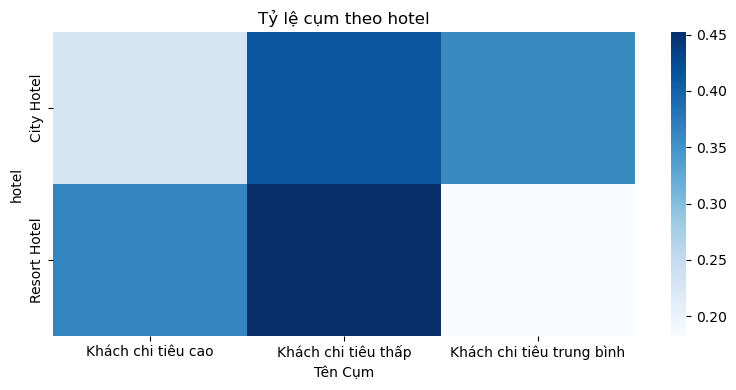

Chi-square p-value giữa Tên Cụm và hotel: 0.0000
→ Có dấu hiệu phụ thuộc mạnh (có thể có bias).

===== TÓM TẮT CHỈ SỐ FAIRNESS (GAP CÀNG NHỎ CÀNG CÔNG BẰNG) =====


,metric,attribute,max_gap
0,Demographic Parity Gap,hotel,0.1759


In [648]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# ==========================
# 0️⃣ Chuẩn bị dữ liệu
# ==========================
# fair_df lấy từ df_display sau phân cụm
fair_df = df_display.copy()
cluster_col = 'Tên Cụm'  # hoặc 'Cụm'

# Lấy các cột categorical còn trong df_display làm thuộc tính “protected”
# Lấy tự động các cột categorical còn lại
protected_cols = fair_df.select_dtypes(include=['object', 'category']).columns.tolist()
protected_cols = [c for c in protected_cols if c != 'Tên Cụm']  # loại bỏ cột cluster

print(f"Các thuộc tính protected được dùng để kiểm tra fairness: {protected_cols}")

# ==========================
# 1️⃣ Demographic Parity: Phân bổ cụm theo từng nhóm protected
# ==========================
print("\n===== DEMOGRAPHIC PARITY =====")

for col in protected_cols:
    print(f"\n--- Phân bổ {cluster_col} theo {col} ---")
    
    ct = pd.crosstab(fair_df[col], fair_df[cluster_col])
    prop = ct.div(ct.sum(axis=1), axis=0)  # tỷ lệ trong mỗi nhóm
    
    print("Bảng đếm:")
    print(ct.head())
    print("\nTỷ lệ phân bổ cụm:")
    print(prop.round(3).head())

    # Vẽ heatmap
    plt.figure(figsize=(8,4))
    sns.heatmap(prop, annot=False, cmap="Blues")
    plt.title(f"Tỷ lệ cụm theo {col}")
    plt.xlabel(cluster_col)
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    # Chi-square test
    chi2, p, dof, ex = chi2_contingency(ct)
    print(f"Chi-square p-value giữa {cluster_col} và {col}: {p:.4f}")
    if p < 0.05:
        print("→ Có dấu hiệu phụ thuộc mạnh (có thể có bias).")
    else:
        print("→ Chưa thấy bằng chứng mạnh về phụ thuộc.")

# ==========================
# 2️⃣ Equal Opportunity: nếu có cột is_canceled
# ==========================
if 'is_canceled' in fair_df.columns:
    print("\n===== EQUAL OPPORTUNITY (Tỷ lệ hủy phòng) =====")
    
    cancel_by_cluster = fair_df.groupby(cluster_col)['is_canceled'].mean()
    print("\nTỷ lệ hủy phòng theo cụm (%):")
    print((cancel_by_cluster*100).round(2))

    for col in protected_cols:
        print(f"\n--- Tỷ lệ hủy phòng theo {cluster_col} và {col} ---")
        cancel_rate = fair_df.groupby([col, cluster_col])['is_canceled'].mean().unstack(cluster_col)
        print((cancel_rate*100).round(2).head())

        plt.figure(figsize=(8,4))
        (cancel_rate*100).plot(kind='bar')
        plt.ylabel("Tỷ lệ hủy phòng (%)")
        plt.title(f"Tỷ lệ hủy phòng theo {col} và {cluster_col}")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# ==========================
# 3️⃣ Tổng hợp Fairness Summary (Gap)
# ==========================
fairness_summary = []

# Demographic Parity Gap
for col in protected_cols:
    ct = pd.crosstab(fair_df[col], fair_df[cluster_col])
    prop = ct.div(ct.sum(axis=1), axis=0)
    max_gap = max([prop[c].max() - prop[c].min() for c in prop.columns])
    
    fairness_summary.append({
        "metric": "Demographic Parity Gap",
        "attribute": col,
        "max_gap": round(float(max_gap), 4)
    })

# Equal Opportunity Gap
if 'is_canceled' in fair_df.columns:
    for col in protected_cols:
        cancel_rate = fair_df.groupby([col, cluster_col])['is_canceled'].mean().unstack(cluster_col)
        max_gap = max([cancel_rate[c].max() - cancel_rate[c].min() for c in cancel_rate.columns])
        fairness_summary.append({
            "metric": "Equal Opportunity Gap (is_canceled)",
            "attribute": col,
            "max_gap": round(float(max_gap), 4)
        })

fairness_summary_df = pd.DataFrame(fairness_summary)
print("\n===== TÓM TẮT CHỈ SỐ FAIRNESS (GAP CÀNG NHỎ CÀNG CÔNG BẰNG) =====")
display(fairness_summary_df)


In [649]:
#Dữ liệu đã phân cụm lần 1 với biến đã onehot scale
model_dt.to_csv('hotel_booking_cleaned_with_clusters1.csv', index=False)

#Dữ liệu đã phân cụm lần 1 với biến gốc
df_display.to_csv("hotel_booking_cleaned_raw_with_clusters1.csv", index=False)

#### Phân cụm chi tiết về khách hàng chi tiêu cao

In [650]:
# Lấy riêng nhóm chi tiêu cao ra
df_raw = pd.read_csv("hotel_booking_cleaned_raw_with_clusters1.csv")                 # dữ liệu thật
df_clustered = pd.read_csv("hotel_booking_cleaned_raw_with_clusters1.csv") # dữ liệu encode+scale

# Gắn cụm lần 1 vào dữ liệu gốc
df_raw["Tên Cụm"] = df_clustered["Tên Cụm"]

# Lấy nhóm chi tiêu cao (dữ liệu GỐC)
df_high = df_raw[df_raw["Tên Cụm"] == "Khách chi tiêu cao"].copy()

print("Số khách chi tiêu cao:", len(df_high))


Số khách chi tiêu cao: 24608


In [651]:
print(df_high.columns.tolist())


['lead_time', 'total_nights', 'adults', 'children', 'babies', 'adr', 'room_price_total', 'booking_changes', 'days_in_waiting_list', 'total_of_special_requests', 'previous_cancellations', 'previous_bookings_not_canceled', 'hotel', 'is_repeated_guest', 'Cụm', 'Tên Cụm']


In [652]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans

df_cluster_high = df_clustered[df_clustered["Tên Cụm"] == "Khách chi tiêu cao"].copy()

# --- Điều chỉnh trọng số các biến gây bias ---
df_cluster_high['adr_adj'] = df_cluster_high['adr'] / 2
df_cluster_high['room_price_total_adj'] = df_cluster_high['room_price_total'] / 2
df_cluster_high['total_nights_adj'] = df_cluster_high['total_nights'] / 2

# Các biến numeric còn lại
sub_numeric = [
    'adr_adj', 'room_price_total_adj', 'total_nights_adj',
    'lead_time', 'total_of_special_requests'
]

# Các biến one-hot
sub_categorical_encoded = [col for col in df_cluster_high.columns if "_" in col]

# Chuẩn hóa
scaler = RobustScaler()
X_sub = scaler.fit_transform(df_cluster_high[sub_numeric + sub_categorical_encoded])




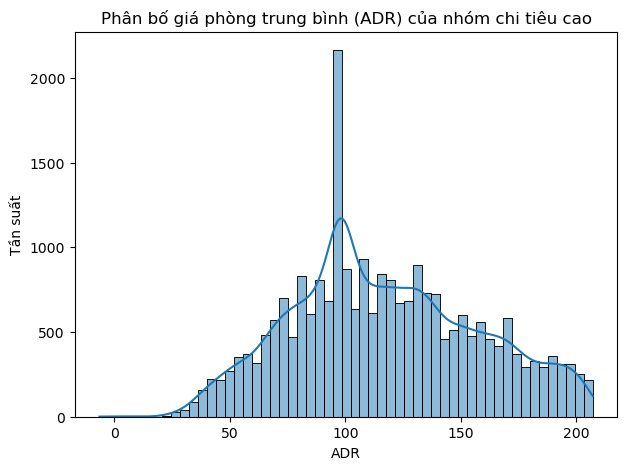

In [653]:
plt.figure(figsize=(7,5))
sns.histplot(df_high['adr'], kde=True)
plt.title("Phân bố giá phòng trung bình (ADR) của nhóm chi tiêu cao")
plt.xlabel("ADR")
plt.ylabel("Tần suất")
plt.show()

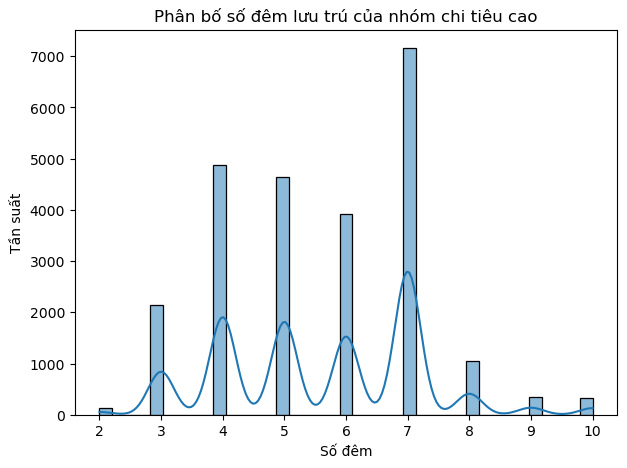

In [654]:


plt.figure(figsize=(7,5))
sns.histplot(df_high['total_nights'], kde=True)
plt.title("Phân bố số đêm lưu trú của nhóm chi tiêu cao")
plt.xlabel("Số đêm")
plt.ylabel("Tần suất")
plt.show()


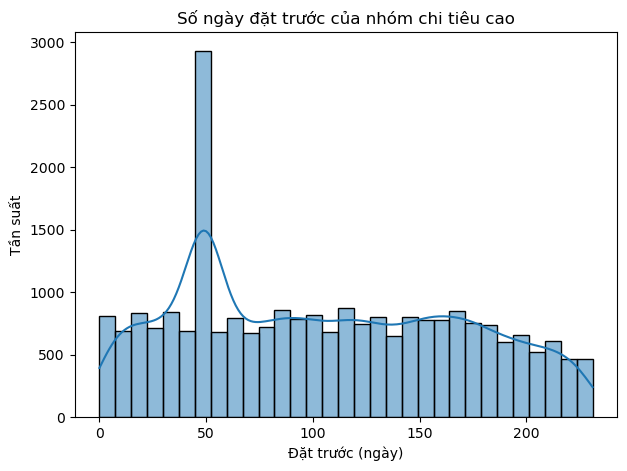

In [655]:
plt.figure(figsize=(7,5))
sns.histplot(df_high['lead_time'], kde=True)
plt.title("Số ngày đặt trước của nhóm chi tiêu cao")
plt.xlabel("Đặt trước (ngày)")
plt.ylabel("Tần suất")
plt.show()


In [656]:
# Phân cụm chi tiết
k2 = 3
kmeans2 = KMeans(n_clusters=k2, random_state=42, n_init=10)

df_cluster_high['Cụm_Chi_Tiết'] = kmeans2.fit_predict(X_sub)
df_high['Cụm_Chi_Tiết'] = df_cluster_high['Cụm_Chi_Tiết'].values


# Tóm tắt đặc trưng trung bình từng sub-cluster
sub_numeric_orig = ['adr', 'room_price_total', 'total_nights', 'lead_time', 'total_of_special_requests']
summary_sub = df_high.groupby('Cụm_Chi_Tiết')[sub_numeric_orig].mean().round(2)

print("=== TÓM TẮT ĐẶC TRƯNG MỖI SUB-CLUSTER ===")
display(summary_sub)
 

=== TÓM TẮT ĐẶC TRƯNG MỖI SUB-CLUSTER ===


,adr,room_price_total,total_nights,lead_time,total_of_special_requests
Cụm_Chi_Tiết,,,,,
0,134.14,455.87,3.99,113.95,0.24
1,151.55,828.01,6.60,96.16,0.75
2,79.87,427.87,6.46,102.24,0.53


In [657]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# --- Chỉ số phân cụm cho sub-cluster ---
# Inertia
inertia_value = kmeans2.inertia_

# Silhouette Score
sil_score = silhouette_score(X_sub, df_high['Cụm_Chi_Tiết'])

# Calinski-Harabasz Index
ch_score = calinski_harabasz_score(X_sub, df_high['Cụm_Chi_Tiết'])

# Davies-Bouldin Index
db_score = davies_bouldin_score(X_sub, df_high['Cụm_Chi_Tiết'])

print("=== Đánh giá chất lượng phân cụm chi tiết (sub-cluster) ===")
print(f"Inertia: {inertia_value:.2f}")
print(f"Silhouette Score: {sil_score:.3f}")
print(f"Calinski-Harabasz Index: {ch_score:.2f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")


=== Đánh giá chất lượng phân cụm chi tiết (sub-cluster) ===
Inertia: 72271.16
Silhouette Score: 0.244
Calinski-Harabasz Index: 10322.03
Davies-Bouldin Index: 1.366


In [658]:
# --- 0) Tạo summary các giá trị trung bình theo cụm chi tiết ---
summary2 = df_high.groupby('Cụm_Chi_Tiết')[sub_numeric_orig].mean()

# Tạo dict để chứa tên sub-cluster
detail_labels = {}

# --- 1) Tạo các ngưỡng Top 20% ---
thr_adr    = summary2['adr'].quantile(0.8)
thr_price  = summary2['room_price_total'].quantile(0.8)
thr_nights = summary2['total_nights'].quantile(0.8)
thr_lead   = summary2['lead_time'].quantile(0.8)
thr_req    = summary2['total_of_special_requests'].quantile(0.8)

# --- 2) Logic gán tên sub-cluster ---
for cid in summary2.index:
    adr_val   = summary2.loc[cid, 'adr']
    price_val = summary2.loc[cid, 'room_price_total']
    nights_val= summary2.loc[cid, 'total_nights']
    lead_val  = summary2.loc[cid, 'lead_time']
    req_val   = summary2.loc[cid, 'total_of_special_requests']
    
    if (adr_val > thr_adr) and (price_val > thr_price) and (nights_val > thr_nights):
        detail_labels[cid] = "Luxury / Premium"
    elif (req_val > thr_req) or (lead_val > thr_lead):
        detail_labels[cid] = "Nhu cầu cao / Kỳ vọng cao"
    else:
        detail_labels[cid] = "Đi công tác / Gia đình / Tiêu chuẩn"

# --- 3) Gán tên vào df_high ---
df_high['Tên_Cụm_Chi_Tiết'] = df_high['Cụm_Chi_Tiết'].map(detail_labels)


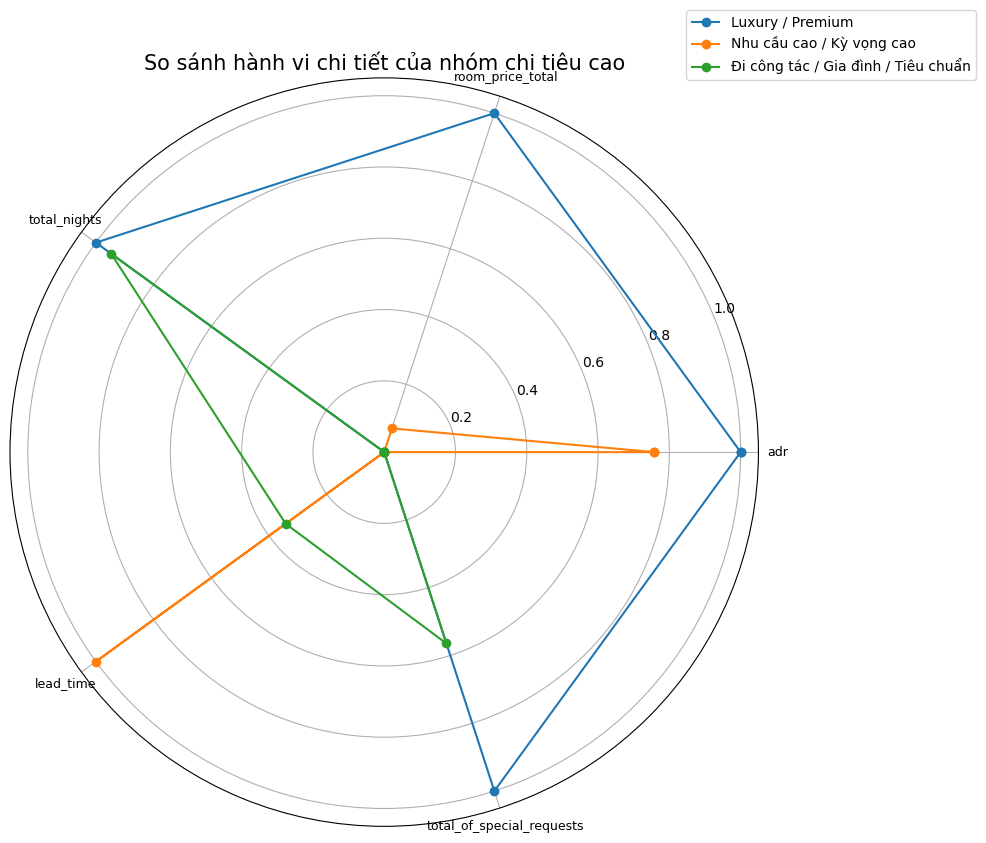

In [659]:
import matplotlib.pyplot as plt
import numpy as np

summary_detail = df_high.groupby('Tên_Cụm_Chi_Tiết')[sub_numeric_orig ].mean()

# Normalize
summary_norm = (summary_detail - summary_detail.min()) / (summary_detail.max() - summary_detail.min())

categories = summary_norm.columns
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10,10))

for cluster in summary_norm.index:
    values = summary_norm.loc[cluster].tolist()
    values += values[:1]
    plt.polar(angles, values, label=cluster, marker='o')

plt.xticks(angles[:-1], categories, fontsize=9)
plt.title("So sánh hành vi chi tiết của nhóm chi tiêu cao", fontsize=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


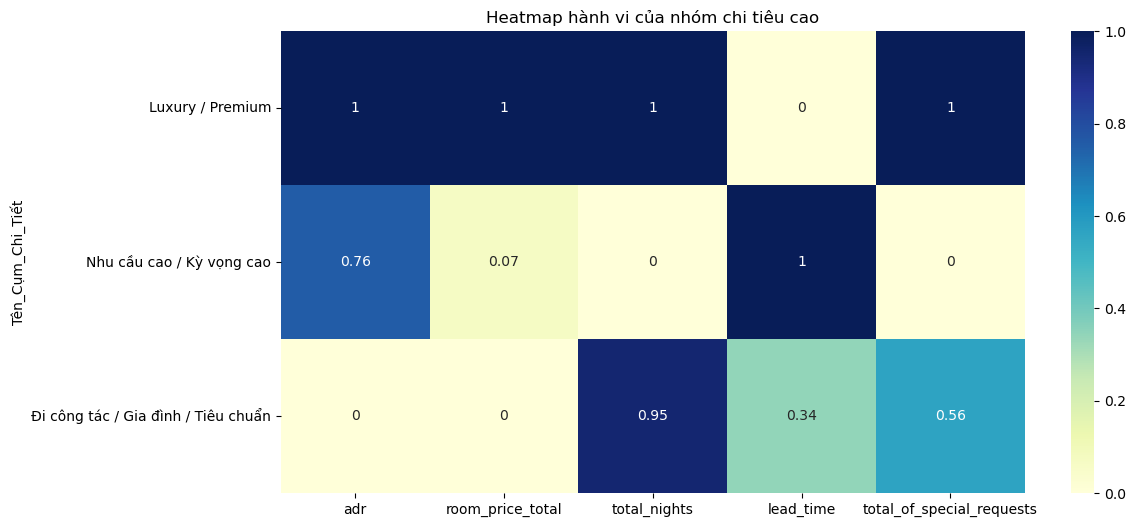

In [660]:
plt.figure(figsize=(12,6))
sns.heatmap(summary_norm, annot=True, cmap='YlGnBu')
plt.title("Heatmap hành vi của nhóm chi tiêu cao")
plt.show()


In [661]:
#Dữ liệu đã phân cụm lần 2 với biến đã onehot scale
df_cluster_high.to_csv('hotel_booking_cleaned_with_clusters2.csv', index=False)

#Dữ liệu đã phân cụm lần 2 với biến gốc
df_high.to_csv("hotel_booking_cleaned_raw_with_clusters2.csv", index=False)

#### Kiểm tra bias phân cụm l2

In [662]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

df_high = pd.read_csv("hotel_booking_cleaned_raw_with_clusters2.csv")

# Protected attributes còn trong dataset
protected_attributes = ['hotel']   # chỉ còn đúng cột này

results = []

print("===== KIỂM TRA BIAS CHO PHÂN CỤM LẦN 2 =====\n")

for attr in protected_attributes:
    print(f"\n===== DEMOGRAPHIC PARITY for {attr} =====\n")

    # Bảng phân bổ theo cụm chi tiết
    tab = pd.crosstab(df_high[attr], df_high['Tên_Cụm_Chi_Tiết'])
    print("Bảng đếm:")
    print(tab, "\n")

    # Tỷ lệ
    ratio = tab.div(tab.sum(axis=1), axis=0).round(3)
    print("Tỷ lệ phân bổ:")
    print(ratio, "\n")

    # Chi-Square test
    chi2, p, _, _ = chi2_contingency(tab)
    print(f"Chi-square p-value: {p:.4f}")

    if p < 0.05:
        print("→ Có dấu hiệu bias (phân bổ không đồng đều).")
    else:
        print("→ Không có bias đáng kể.")

    # demographic parity gap
    gap = ratio.max().max() - ratio.min().min()

    results.append({
        'metric': 'Demographic Parity Gap',
        'attribute': attr,
        'max_gap': float(gap)
    })

print("\n===== TÓM TẮT KẾT QUẢ =====")
summary = pd.DataFrame(results)
display(summary)


===== KIỂM TRA BIAS CHO PHÂN CỤM LẦN 2 =====


===== DEMOGRAPHIC PARITY for hotel =====

Bảng đếm:
Tên_Cụm_Chi_Tiết  Luxury / Premium  Nhu cầu cao / Kỳ vọng cao  Đi công tác / Gia đình / Tiêu chuẩn
hotel                                                                                             
City Hotel                    2611                       6507                                 3088
Resort Hotel                  3497                       2363                                 6542 

Tỷ lệ phân bổ:
Tên_Cụm_Chi_Tiết  Luxury / Premium  Nhu cầu cao / Kỳ vọng cao  Đi công tác / Gia đình / Tiêu chuẩn
hotel                                                                                             
City Hotel                   0.214                      0.533                                0.253
Resort Hotel                 0.282                      0.191                                0.527 

Chi-square p-value: 0.0000
→ Có dấu hiệu bias (phân bổ không đồng đều).

===== TÓM TẮT KẾT

,metric,attribute,max_gap
0,Demographic Parity Gap,hotel,0.342
